# Nucleon Spatial Charge and Magnetization Distribution Calculator

## Overview
This Python script computes the 3D and 2D spatial charge and magnetization distributions of the nucleon by performing Fourier transforms on parameterized momentum-space electromagnetic form factors. It calculates the non-relativistic 3D Breit frame distributions ($\rho_E(r)$ and $\rho_M(r)$) and the relativistic 2D Light-Front transverse distributions ($\rho_{ch}(b)$ and $\rho_{m}(b)$), complete with error propagation based on experimental fit uncertainties.

## 1. Physical Constants
The script defines standard constants required for hadronic kinematics and unit conversions:
* **`HBARC` (0.1973269804):** Conversion factor $\hbar c$ used to convert momentum transfer $Q$ from GeV to inverse femtometers ($\text{fm}^{-1}$).
* **`M_P` (0.938272 GeV):** Proton mass, required to calculate the kinematic factor $\tau = Q^2 / 4M_p^2$.
* **`MU_P` / `MU_N`:** Magnetic moments of the proton and neutron, used to properly normalize the magnetic form factor $G_M(Q^2)$ at $Q^2 = 0$.

## 2. Form Factor Parameterization (`GetFF`)
The core empirical data is driven by the `GetFF(kID, kQ2)` function, which evaluates experimental global fits.
* **Central Values:** Evaluated using a truncated $z$-expansion mathematical technique to ensure analytic continuation properties of the form factors in the timelike region. The function returns a normalized ratio $G/G_D$, where $G_D$ is the standard dipole form factor.
* **Error Parameterization:** The relative uncertainty is calculated using a piecewise logarithmic function of $Q^2$. 
* **Domain Protections:** The integration routinely probes $Q^2 \rightarrow 0$. A small lower bound (`if kQ2 <= 0.0: kQ2 = 1e-10`) prevents `log10()` math domain errors at the lower integration limit.

## 3. Observable Extraction (Wrappers)
To keep the integration routines clean, wrapper functions construct the physical form factors from the `GetFF` outputs:
* **`gep_central` / `gmp_central`:** Multiplies the `GetFF` output by the dipole form factor $G_D(Q^2)$ and the appropriate magnetic moment to recover the true Sachs form factors $G_E^p$ and $G_M^p$.
* **`f1p_central` / `f2p_central`:** Constructs the Dirac ($F_1$) and Pauli ($F_2$) form factors, which are required for relativistic Light-Front physics, using the standard Sachs relations:
  $$F_1(Q^2) = \frac{G_E(Q^2) + \tau G_M(Q^2)}{1 + \tau}$$
  $$F_2(Q^2) = \frac{G_M(Q^2) - G_E(Q^2)}{1 + \tau}$$
* **Error Wrappers:** Functions like `f1p_error` and `f2p_error` propagate the uncertainties from $G_E$ and $G_M$ using standard quadrature rules.

## 4. Spatial Density Integrations
The conversion from momentum transfer $Q^2$ to spatial coordinates $r$ or $b$ is handled via numerical integration using `scipy.integrate.quad`.

### 3D Breit Frame Densities (`rho_3d_breit`)
Calculates the standard non-relativistic charge and magnetization densities. Because the Fourier transform for both $G_E$ and $G_M$ is mathematically identical in this frame, the same function is used for both observables:
$$\rho_{E,M}(r) = \frac{1}{2\pi^2} \int_0^{Q_{max}} G_{E,M}(Q^2) \frac{\sin(qr)}{qr} q^2 dq$$
* Handles the $r \rightarrow 0$ limit analytically by setting $\sin(qr)/qr \rightarrow 1$ to prevent division by zero.

### 2D Light-Front Charge Density (`rho_2d_lightfront`)
Calculates the frame-independent transverse charge density as a function of the impact parameter $b$:
$$\rho_{ch}(b) = \frac{1}{2\pi} \int_0^{Q_{max}} F_1(Q^2) J_0(q b) q dq$$
* Utilizes the 0th-order Bessel function of the first kind (`scipy.special.j0`).

### 2D Light-Front Magnetization Density (`rho_2d_lightfront_magnetic`)
Calculates the frame-independent transverse anomalous magnetization density:
$$\rho_{m}(b) = \frac{1}{2\pi} \int_0^{Q_{max}} F_2(Q^2) J_1(q b) q^2 dq$$
* Utilizes the 1st-order Bessel function of the first kind (`scipy.special.j1`).
* Includes an extra momentum factor $q$ from the cross product in the magnetic dipole moment formulation, altering the physical dimensions of the output to $\text{fm}^{-3}$.

**Numerical Stability Note:** Instead of integrating to $\infty$, the upper bounds are truncated at $Q = 15 \text{ GeV}$ (corresponding to $Q^2 = 225 \text{ GeV}^2$). Because the form factors effectively vanish at this scale, the truncation prevents `scipy.integrate.quad` from mapping infinite oscillations into a microscopic numerical domain, eliminating `IntegrationWarning` roundoff errors.

## 5. Error Envelope Propagation
The `calculate_density_envelope` function computes the $1\sigma$ upper and lower uncertainty bands on the spatial distributions.
* It assumes a conservative $100\%$ correlation across $Q^2$ by directly evaluating the integration over $F(Q^2) + \delta F(Q^2)$ and $F(Q^2) - \delta F(Q^2)$.
* It applies a pointwise `np.maximum` and `np.minimum` check, since oscillatory integrands (like Bessel functions) can occasionally cause the "upper" form factor bound to yield a lower spatial density at specific radii.

## 6. Execution and Output
The `__main__` block initializes a spatial grid (`np.linspace(0.0, 2.5, 40)`) for both $r$ and $b$, running the respective integrals for all four density functions. The results are visualized in a $2 \times 2$ grid via `matplotlib`, displaying the 3D Breit distributions in the left column, the 2D Light-Front distributions in the right column, and highlighting both the central values and the shaded uncertainty regions.

In [1]:
import numpy as np
from math import sqrt, log10
from scipy.integrate import quad
from scipy.special import j0
import matplotlib.pyplot as plt

# ==========================================
# Physical Constants
# ==========================================
HBARC = 0.1973269804  # hbar * c in GeV * fm
M_P = 0.938272        # Proton mass in GeV
MU_P = 2.79284356     # Proton magnetic moment mu_p
MU_N = -1.91304272    # Neutron magnetic moment mu_n

# ==========================================
# Parameterized Form Factor Functions (Integrated)
# ==========================================
def GetFF(kID, kQ2):
    ### GEp->kID=1, GMp->kID=2, GEn->kID=3, GMn->kID=4
    if kID < 1 or kID > 4:
        print('*** ERROR***, kID is not any of [1->GEp, 2->GMp, 3->GEn, 4->GMn]')
        return -1000, -1000

    #### z-Expansion Parameters for Form Factor Values
    GN_Coef_Fit = np.zeros((4,13), dtype=float)
    GN_Coef_Fit[0] = np.array([0.239163298067,  -1.10985857441,  1.44438081306,  0.479569465603,  -2.28689474187,  1.12663298498,  1.25061984354,  -3.63102047159,  4.08221702379,  0.504097346499,  -5.08512046051,  3.96774254395,  -0.981529071103]) #GEp
    GN_Coef_Fit[1] = np.array([0.264142994136, -1.09530612212, 1.21855378178, 0.661136493537, -1.40567892503, -1.35641843888, 1.44702915534, 4.2356697359, -5.33404565341, -2.91630052096, 8.70740306757, -5.70699994375, 1.28081437589]) #GMp
    GN_Coef_Fit[2] = np.array([0.048919981379,-0.064525053912,-0.240825897382,0.392108744873, 0.300445258602,-0.661888687179,-0.175639769687, 0.624691724461,-0.077684299367,-0.236003975259, 0.090401973470, 0.0, 0.0]) #GEn
    GN_Coef_Fit[3] = np.array([0.257758326959,-1.079540642058, 1.182183812195,0.711015085833,-1.348080936796,-1.662444025208, 2.624354426029, 1.751234494568,-4.922300878888, 3.197892727312,-0.712072389946, 0.0, 0.0]) #GMn

    #### Parameters for Form Factor Errors
    parL = np.zeros((4,2), dtype=float)
    parM = np.zeros((4,15), dtype=float)
    parH = np.zeros((4,3), dtype=float)
    
    ## GEp:
    parL[0] = np.array([-0.97775297,  0.99685273])
    parM[0] = np.array([ -1.97750308e+00,  -4.46566998e-01,   2.94508717e-01,   1.54467525e+00, 9.05268347e-01,  -6.00008111e-01,  -1.10732394e+00,  -9.85982716e-02, 4.63035988e-01,   1.37729116e-01,  -7.82991627e-02,  -3.63056932e-02, 2.64219326e-03,   3.13261383e-03,   3.89593858e-04 ])
    parH[0] = np.array([ 0.78584754,  1.89052183, -0.4104746])

    #GMp:
    parL[1] = np.array([-0.68452707,  0.99709151])
    parM[1] = np.array([ -1.76549673e+00,   1.67218457e-01,  -1.20542733e+00,  -4.72244127e-01, 1.41548871e+00,   6.61320779e-01,  -8.16422909e-01,  -3.73804477e-01, 2.62223992e-01,   1.28886639e-01,  -3.90901510e-02,  -2.44995181e-02, 8.34270064e-04,   1.88226433e-03,   2.43073327e-04])
    parH[1] = np.array([  0.80374002,  1.98005828, -0.69700928])
    
    #GEn:
    parL[2] = np.array([-2.02311829, 1.00066282])
    parM[2] = np.array([-2.07343771e+00,   1.13218347e+00,   1.03946682e+00,  -2.79708561e-01, -3.39166129e-01,   1.98498974e-01,  -1.45403679e-01,  -1.21705930e-01, 1.14234312e-01,   5.69989513e-02,  -2.33664051e-02,  -1.35740738e-02, 7.84044667e-04,   1.19890550e-03,   1.55012141e-04,])
    parH[2] = np.array([0.4553596, 1.95063341, 0.32421279])

    #GMn:
    parL[3] = np.array([-0.20765505, 0.99767103])
    parM[3] = np.array([  -2.07087611e+00,   4.32385770e-02,  -3.28705077e-01,   5.08142662e-01, 1.89103676e+00,   1.36784324e-01,  -1.47078994e+00,  -3.54336795e-01, 4.98368396e-01,   1.77178596e-01,  -7.34859451e-02,  -3.72184066e-02, 1.97024963e-03,   2.88676628e-03,   3.57964735e-04])
    parH[3] = np.array([ 0.50859057, 1.96863291, 0.2321395])

    ## Apply the z-expansion formula
    tcut = 0.0779191396
    t0 = -0.7
    z = (sqrt(tcut+kQ2)-sqrt(tcut-t0))/(sqrt(tcut+kQ2)+sqrt(tcut-t0)) 
    GNQ2 = np.array([GN_Coef_Fit[kID-1][i]*(z**i) for i in range(0, len(GN_Coef_Fit[kID-1]))]).sum() 
    GDip = 1.0 / (1.0 + kQ2/0.71)**2
    GNGD_Fit = GNQ2 / GDip 

    ## Prevent domain error in log10 if integrator tests Q2 = 0
    if kQ2 <= 0.0:
        kQ2 = 1e-10

    ## Apply the parameterization formula for error
    lnQ2 = log10(kQ2)
    lnGNGD_Err=0.0
    if kQ2 < 1e-3:
        lnGNGD_Err = parL[kID-1][0] + parL[kID-1][1]*lnQ2
    elif kQ2 > 1e2:
        # Prevent negative sqrt domain error
        val = lnQ2 - parH[kID-1][1]
        lnGNGD_Err = parH[kID-1][0]*np.sqrt(max(val, 0.0)) + parH[kID-1][2]
    else:
        lnGNGD_Err = np.array([parM[kID-1][i]*(lnQ2**i) for i in range(0, len(parM[kID-1]))]).sum() 
    GNGD_Err = 10.**(lnGNGD_Err)    

    return GNGD_Fit, GNGD_Err

# ==========================================
# Proton Wrappers to Extract Physical Observables
# ==========================================
def dip(Q2):
    return 1.0 / (1.0 + Q2 / 0.71)**2

def gep_central(Q2):
    fit, _ = GetFF(1, Q2)
    return fit * dip(Q2) * 1.0  # GEp(0) = 1

def gep_error(Q2):
    _, err = GetFF(1, Q2)
    return err * dip(Q2) * 1.0

def gmp_central(Q2):
    fit, _ = GetFF(2, Q2)
    return fit * dip(Q2) * MU_P

def gmp_error(Q2):
    _, err = GetFF(2, Q2)
    return err * dip(Q2) * MU_P

def f1p_central(Q2):
    """Calculates Dirac form factor F1p from GEp and GMp."""
    tau = Q2 / (4.0 * M_P**2)
    return (gep_central(Q2) + tau * gmp_central(Q2)) / (1.0 + tau)

def f1p_error(Q2):
    """Calculates F1p error propagating GEp and GMp uncertainties."""
    tau = Q2 / (4.0 * M_P**2)
    dge = gep_error(Q2)
    dgm = gmp_error(Q2)
    return (1.0 / (1.0 + tau)) * np.sqrt(dge**2 + (tau * dgm)**2)

def f2p_central(Q2):
    """Calculates Pauli form factor F2p from GEp and GMp."""
    tau = Q2 / (4.0 * M_P**2)
    return (gmp_central(Q2) - gep_central(Q2)) / (1.0 + tau)

def f2p_error(Q2):
    """Calculates F2p error propagating GEp and GMp uncertainties."""
    tau = Q2 / (4.0 * M_P**2)
    dge = gep_error(Q2)
    dgm = gmp_error(Q2)
    return (1.0 / (1.0 + tau)) * np.sqrt(dge**2 + dgm**2)

# ==========================================
# Neutron-Specific Constants
# ==========================================
MU_N = -1.91304272    # Neutron magnetic moment mu_n

# ==========================================
# Neutron Form Factor Wrappers
# ==========================================
def gen_central(Q2):
    fit, _ = GetFF(3, Q2)
    return fit * dip(Q2) * 1.0  # Normalized to 1 

def gen_error(Q2):
    _, err = GetFF(3, Q2)
    return err * dip(Q2) * 1.0

def gmn_central(Q2):
    fit, _ = GetFF(4, Q2)
    return fit * dip(Q2) * MU_N

def gmn_error(Q2):
    _, err = GetFF(4, Q2)
    return err * dip(Q2) * abs(MU_N)  # Absolute value to prevent inverted error bounds

def f1n_central(Q2):
    """Calculates Dirac form factor F1n from GEn and GMn."""
    tau = Q2 / (4.0 * M_P**2)
    return (gen_central(Q2) + tau * gmn_central(Q2)) / (1.0 + tau)

def f1n_error(Q2):
    tau = Q2 / (4.0 * M_P**2)
    dge = gen_error(Q2)
    dgm = gmn_error(Q2)
    return (1.0 / (1.0 + tau)) * np.sqrt(dge**2 + (tau * dgm)**2)

def f2n_central(Q2):
    """Calculates Pauli form factor F2n from GEn and GMn."""
    tau = Q2 / (4.0 * M_P**2)
    return (gmn_central(Q2) - gen_central(Q2)) / (1.0 + tau)

def f2n_error(Q2):
    tau = Q2 / (4.0 * M_P**2)
    dge = gen_error(Q2)
    dgm = gmn_error(Q2)
    return (1.0 / (1.0 + tau)) * np.sqrt(dge**2 + dgm**2)
    
# ==========================================
# Density Calculation Functions
# ==========================================
def rho_3d_breit(r_fm, func_central):
    def integrand(Q_GeV):
        GE = func_central(Q_GeV**2)
        q_fm_inv = Q_GeV / HBARC
        if r_fm == 0:
            sin_term = 1.0
        else:
            qr = q_fm_inv * r_fm
            sin_term = np.sin(qr) / qr
        return GE * sin_term * (Q_GeV**2)

    # FIX: Integrate up to Q = 15 GeV instead of np.inf, increase limit
    integral, _ = quad(integrand, 0, 15.0, limit=1000)
    
    prefactor = 1.0 / (2 * np.pi**2 * HBARC**3)
    return prefactor * integral

def rho_2d_lightfront_charge(b_fm, func_central):
    def integrand(Q_GeV):
        F1 = func_central(Q_GeV**2)
        q_fm_inv = Q_GeV / HBARC
        qb = q_fm_inv * b_fm
        return F1 * j0(qb) * Q_GeV

    # FIX: Integrate up to Q = 15 GeV instead of np.inf, increase limit
    integral, _ = quad(integrand, 0, 15.0, limit=1000)
    
    prefactor = 1.0 / (2 * np.pi * HBARC**2)
    return prefactor * integral
from scipy.special import j0, j1  # Make sure j1 is imported at the top of your script

def rho_2d_lightfront_magnetic(b_fm, func_central):
    """Calculates the 2D transverse anomalous magnetization density."""
    def integrand(Q_GeV):
        F2 = func_central(Q_GeV**2)
        q_fm_inv = Q_GeV / HBARC
        qb = q_fm_inv * b_fm
        
        # Integration element is F2 * J1(qb) * q^2 dq
        # Converting q to Q gives Q^2 dQ / (HBARC)^3
        return F2 * j1(qb) * (Q_GeV**2)

    # Integrate to Q = 15 GeV to avoid warnings
    integral, _ = quad(integrand, 0, 15.0, limit=1000)
    
    # Apply the prefactor: 1 / (2 * pi * (hbar*c)^3)
    prefactor = 1.0 / (2 * np.pi * HBARC**3)
    
    return prefactor * integral
    
def calculate_density_envelope(coords, func_cent, func_err, density_calc):
    rho_cent = np.array([density_calc(c, func_cent) for c in coords])
    
    func_up = lambda Q2: func_cent(Q2) + func_err(Q2)
    func_down = lambda Q2: func_cent(Q2) - func_err(Q2)
    
    rho_up = np.array([density_calc(c, func_up) for c in coords])
    rho_down = np.array([density_calc(c, func_down) for c in coords])
    
    rho_max = np.maximum(rho_up, rho_down)
    rho_min = np.minimum(rho_up, rho_down)
    
    return rho_cent, rho_min, rho_max



# Plot Form Factor Distributions

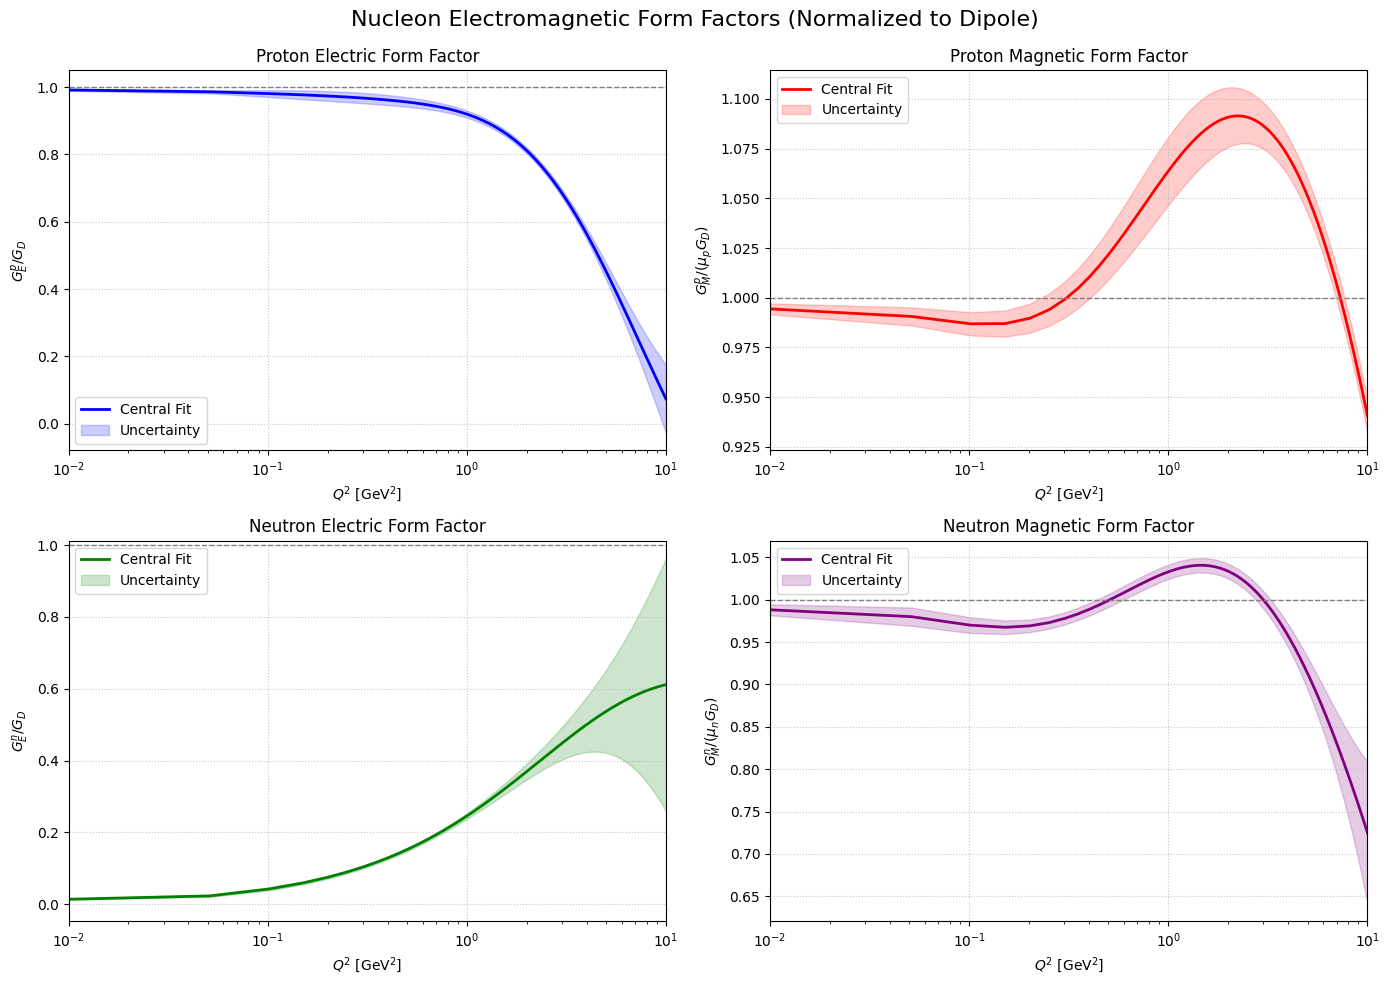

In [2]:
# ==========================================
# Compute Data Arrays
# ==========================================
# Generate a dense array of Q^2 values (avoid exactly zero for plotting log10 logic)
Q2_vals = np.linspace(0.001, 10.0, 200)

# Retrieve Form Factor outputs using list comprehensions and zip them into arrays
gep_fit, gep_err = map(np.array, zip(*[GetFF(1, q) for q in Q2_vals]))
gmp_fit, gmp_err = map(np.array, zip(*[GetFF(2, q) for q in Q2_vals]))
gen_fit, gen_err = map(np.array, zip(*[GetFF(3, q) for q in Q2_vals]))
gmn_fit, gmn_err = map(np.array, zip(*[GetFF(4, q) for q in Q2_vals]))

# ==========================================
# Plotting routine
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Nucleon Electromagnetic Form Factors (Normalized to Dipole)', fontsize=16)

def plot_ff(ax, Q2, fit, err, color, title, ylabel):
    ax.plot(Q2, fit, color=color, linewidth=2, label='Central Fit')
    ax.fill_between(Q2, fit - err, fit + err, color=color, alpha=0.2, label='Uncertainty')
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(r'$Q^2 \ [\mathrm{GeV}^2]$')
    ax.set_ylabel(ylabel)
    ax.set_xlim(0.01, 10)
    ax.set_xscale('log')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='best')

# Top-Left: GEp
plot_ff(axs[0, 0], Q2_vals, gep_fit, gep_err, 'blue', 
        'Proton Electric Form Factor', r'$G_E^p / G_D$')

# Top-Right: GMp
plot_ff(axs[0, 1], Q2_vals, gmp_fit, gmp_err, 'red', 
        'Proton Magnetic Form Factor', r'$G_M^p / (\mu_p G_D)$')

# Bottom-Left: GEn
plot_ff(axs[1, 0], Q2_vals, gen_fit, gen_err, 'green', 
        'Neutron Electric Form Factor', r'$G_E^n / G_D$')

# Bottom-Right: GMn
plot_ff(axs[1, 1], Q2_vals, gmn_fit, gmn_err, 'purple', 
        'Neutron Magnetic Form Factor', r'$G_M^n / (\mu_n G_D)$')

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Leave space for suptitle
plt.show()

Calculating spatial distributions (this may take a few seconds)...


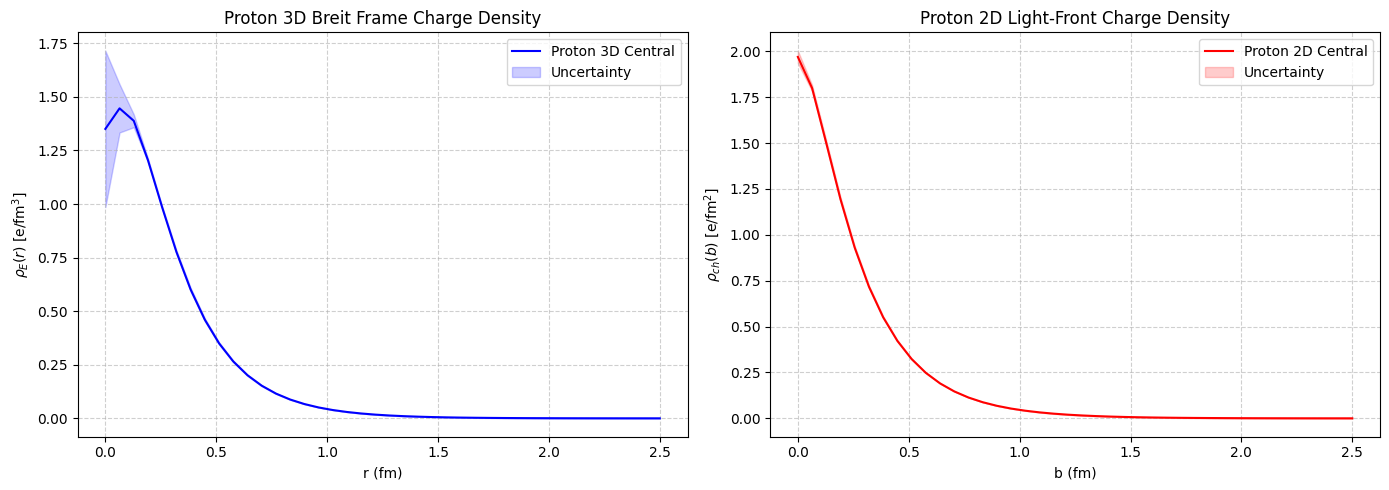

In [5]:
# ==========================================
# Execution and Plotting
# ==========================================
if __name__ == "__main__":
    print("Calculating spatial distributions (this may take a few seconds)...")
    
    r_values = np.linspace(0.0, 2.5, 40)
    b_values = np.linspace(0.0, 2.5, 40)

    # Calculate 3D Breit Density for the Proton (uses GEp)
    rho3d_cent, rho3d_min, rho3d_max = calculate_density_envelope(
        r_values, gep_central, gep_error, rho_3d_breit
    )

    # Calculate 2D Light-Front Density for the Proton (uses F1p)
    rho2d_cent, rho2d_min, rho2d_max = calculate_density_envelope(
        b_values, f1p_central, f1p_error, rho_2d_lightfront_charge
    )

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # 3D Plot (Breit Frame)
    ax1.plot(r_values, rho3d_cent, 'b-', label='Proton 3D Central')
    ax1.fill_between(r_values, rho3d_min, rho3d_max, color='blue', alpha=0.2, label='Uncertainty')
    ax1.set_xlabel('r (fm)')
    ax1.set_ylabel('$\\rho_E(r)$ [e/fm$^3$]')
    ax1.set_title('Proton 3D Breit Frame Charge Density')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # 2D Plot (Light-Front)
    ax2.plot(b_values, rho2d_cent, 'r-', label='Proton 2D Central')
    ax2.fill_between(b_values, rho2d_min, rho2d_max, color='red', alpha=0.2, label='Uncertainty')
    ax2.set_xlabel('b (fm)')
    ax2.set_ylabel('$\\rho_{ch}(b)$ [e/fm$^2$]')
    ax2.set_title('Proton 2D Light-Front Charge Density')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Plot Proton Electric and Magnetic Charge Distributions

Calculating spatial distributions (this will take a moment)...


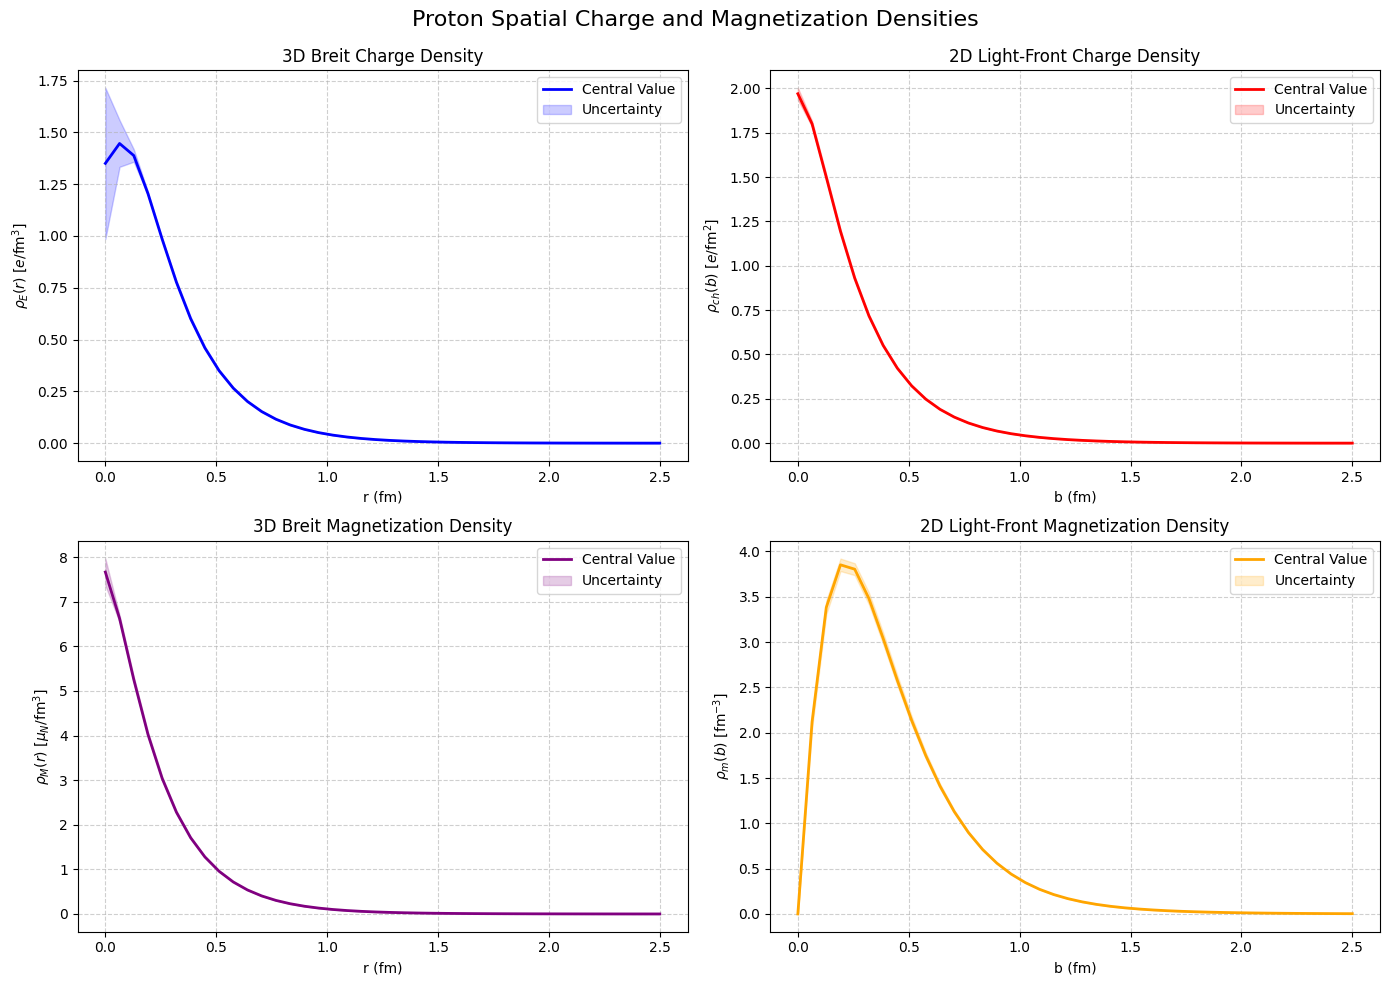

In [6]:
if __name__ == "__main__":
    print("Calculating spatial distributions (this will take a moment)...")
    
    r_values = np.linspace(0.0, 2.5, 40)
    b_values = np.linspace(0.0, 2.5, 40)

    # --- 1. Charge Densities ---
    rho3d_E_cent, rho3d_E_min, rho3d_E_max = calculate_density_envelope(
        r_values, gep_central, gep_error, rho_3d_breit
    )
    rho2d_ch_cent, rho2d_ch_min, rho2d_ch_max = calculate_density_envelope(
        b_values, f1p_central, f1p_error, rho_2d_lightfront_charge
    )

    # --- 2. Magnetic Densities ---
    # 3D uses gmp and the standard Breit integrator
    rho3d_M_cent, rho3d_M_min, rho3d_M_max = calculate_density_envelope(
        r_values, gmp_central, gmp_error, rho_3d_breit
    )
    # 2D uses f2p and the magnetic Light-Front integrator
    rho2d_m_cent, rho2d_m_min, rho2d_m_max = calculate_density_envelope(
        b_values, f2p_central, f2p_error, rho_2d_lightfront_magnetic
    )

    # --- 3. Plotting ---
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Proton Spatial Charge and Magnetization Densities', fontsize=16)

    def plot_density(ax, x_vals, cent, dmin, dmax, color, title, xlabel, ylabel):
        ax.plot(x_vals, cent, color=color, linewidth=2, label='Central Value')
        ax.fill_between(x_vals, dmin, dmax, color=color, alpha=0.2, label='Uncertainty')
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()

    # Top-Left: 3D Charge
    plot_density(axs[0, 0], r_values, rho3d_E_cent, rho3d_E_min, rho3d_E_max, 
                 'blue', '3D Breit Charge Density', 'r (fm)', r'$\rho_E(r) \ [e/\mathrm{fm}^3]$')

    # Bottom-Left: 3D Magnetic
    plot_density(axs[1, 0], r_values, rho3d_M_cent, rho3d_M_min, rho3d_M_max, 
                 'purple', '3D Breit Magnetization Density', 'r (fm)', r'$\rho_M(r) \ [\mu_N/\mathrm{fm}^3]$')

    # Top-Right: 2D Charge
    plot_density(axs[0, 1], b_values, rho2d_ch_cent, rho2d_ch_min, rho2d_ch_max, 
                 'red', '2D Light-Front Charge Density', 'b (fm)', r'$\rho_{ch}(b) \ [e/\mathrm{fm}^2]$')

    # Bottom-Right: 2D Magnetic
    plot_density(axs[1, 1], b_values, rho2d_m_cent, rho2d_m_min, rho2d_m_max, 
                 'orange', '2D Light-Front Magnetization Density', 'b (fm)', r'$\rho_{m}(b) \ [\mathrm{fm}^{-3}]$')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

# Plot Neutron charge distributions

In [8]:
# ==========================================
# Neutron Execution and Plotting Block
# ==========================================
print("Calculating neutron spatial distributions...")

# Ensure spatial arrays exist
r_values = np.linspace(0.0, 2.5, 40)
b_values = np.linspace(0.0, 2.5, 40)

# --- 1. Neutron Charge Densities ---
rho3d_E_cent_n, rho3d_E_min_n, rho3d_E_max_n = calculate_density_envelope(
    r_values, gen_central, gen_error, rho_3d_breit
)
rho2d_ch_cent_n, rho2d_ch_min_n, rho2d_ch_max_n = calculate_density_envelope(
    b_values, f1n_central, f1n_error, rho_2d_lightfront_charge
)

# --- 2. Neutron Magnetic Densities ---
rho3d_M_cent_n, rho3d_M_min_n, rho3d_M_max_n = calculate_density_envelope(
    r_values, gmn_central, gmn_error, rho_3d_breit
)
rho2d_m_cent_n, rho2d_m_min_n, rho2d_m_max_n = calculate_density_envelope(
    b_values, f2n_central, f2n_error, rho_2d_lightfront_magnetic
)

Calculating neutron spatial distributions...


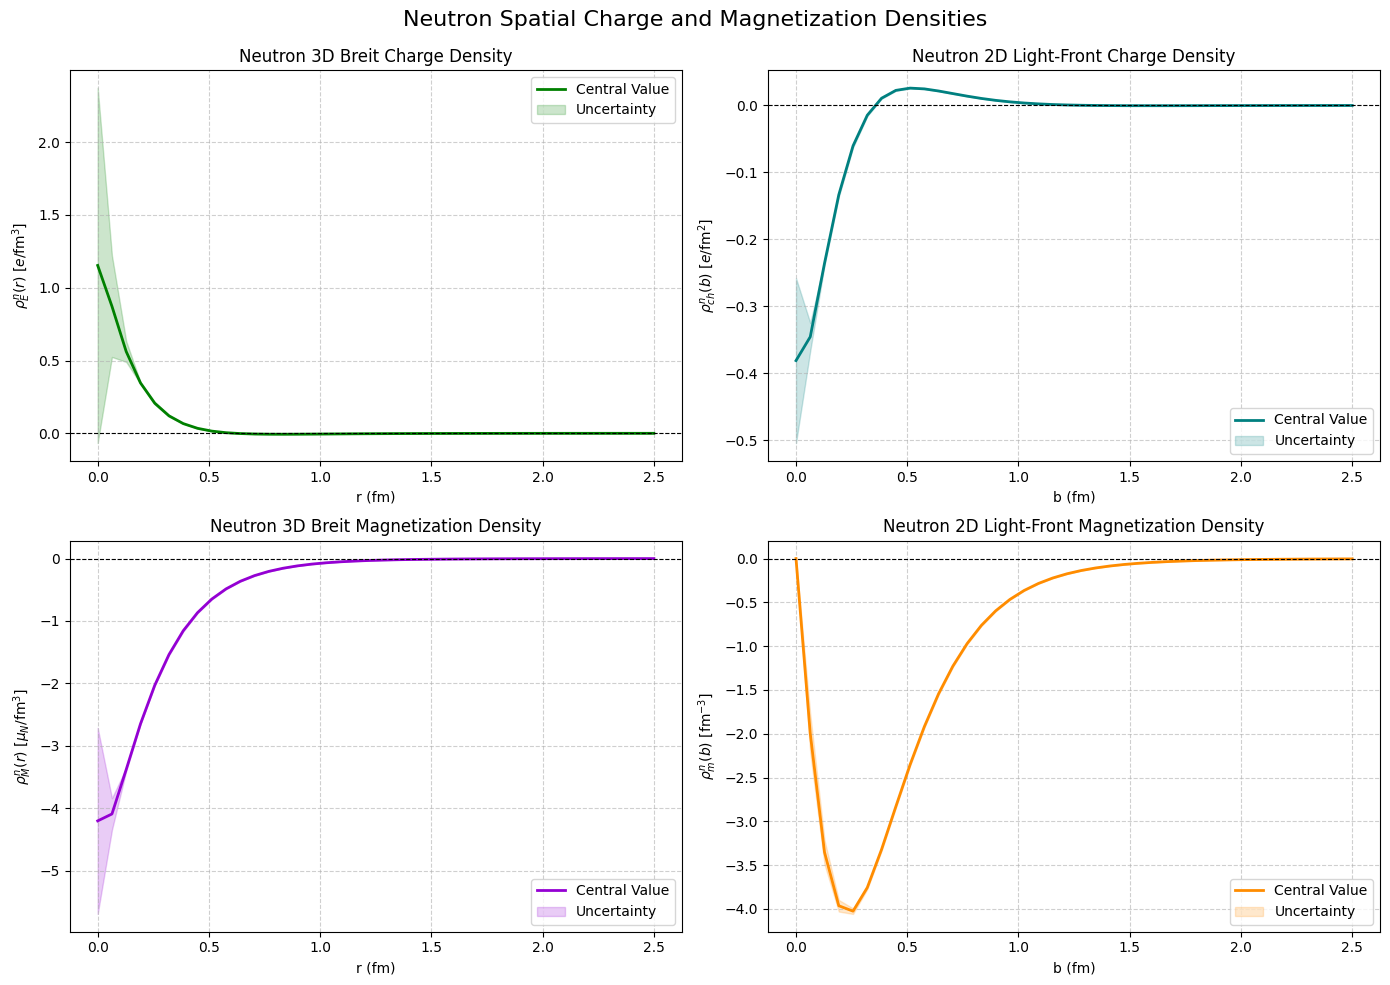

In [9]:
# --- 3. Plotting ---
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Neutron Spatial Charge and Magnetization Densities', fontsize=16)

def plot_neutron_density(ax, x_vals, cent, dmin, dmax, color, title, xlabel, ylabel):
    ax.plot(x_vals, cent, color=color, linewidth=2, label='Central Value')
    ax.fill_between(x_vals, dmin, dmax, color=color, alpha=0.2, label='Uncertainty')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--') # Emphasize 0 line
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    #ax.set_yscale('log')
    #ax.set_ylim(0.01, 10)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

# Top-Left: 3D Charge
plot_neutron_density(axs[0, 0], r_values, rho3d_E_cent_n, rho3d_E_min_n, rho3d_E_max_n, 
                     'green', 'Neutron 3D Breit Charge Density', 'r (fm)', r'$\rho_E^n(r) \ [e/\mathrm{fm}^3]$')

# Bottom-Left: 3D Magnetic
plot_neutron_density(axs[1, 0], r_values, rho3d_M_cent_n, rho3d_M_min_n, rho3d_M_max_n, 
                     'darkviolet', 'Neutron 3D Breit Magnetization Density', 'r (fm)', r'$\rho_M^n(r) \ [\mu_N/\mathrm{fm}^3]$')

# Top-Right: 2D Charge
plot_neutron_density(axs[0, 1], b_values, rho2d_ch_cent_n, rho2d_ch_min_n, rho2d_ch_max_n, 
                     'teal', 'Neutron 2D Light-Front Charge Density', 'b (fm)', r'$\rho_{ch}^n(b) \ [e/\mathrm{fm}^2]$')

# Bottom-Right: 2D Magnetic
plot_neutron_density(axs[1, 1], b_values, rho2d_m_cent_n, rho2d_m_min_n, rho2d_m_max_n, 
                     'darkorange', 'Neutron 2D Light-Front Magnetization Density', 'b (fm)', r'$\rho_{m}^n(b) \ [\mathrm{fm}^{-3}]$')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

# 夸克味道分离与 2D 光前电磁荷分布计算说明

## 1. 物理背景与核心假设

在提取单个夸克味道（$u$ 和 $d$ 夸克）的空间分布时，核心物理基础是**同位旋对称性（Isospin Symmetry）/电荷对称性**。在强相互作用下，我们假设上夸克（$u$）和下夸克（$d$）的动力学行为是高度对称的。

基于此假设，核子内部的夸克分布满足以下交叉对应关系：
* 质子（$p$）中的 $u$ 夸克分布等同于中子（$n$）中的 $d$ 夸克分布。
* 质子（$p$）中的 $d$ 夸克分布等同于中子（$n$）中的 $u$ 夸克分布。

核子的狄拉克形状因子 $F_1(Q^2)$ 描述了自旋不翻转的电磁相互作用，它是核子内部各夸克形状因子按其所带分数电荷加权的总和。

## 2. 数学推导与核心公式

### 2.1 形状因子的线性组合
设 $F_1^u(Q^2)$ 和 $F_1^d(Q^2)$ 分别代表**质子内部** $u$ 夸克和 $d$ 夸克的数量形状因子（未乘以电荷）。根据夸克模型（质子包含 $uud$，中子包含 $udd$），核子的狄拉克形状因子可以写为：

$$F_1^p(Q^2) = e_u F_1^u(Q^2) + e_d F_1^d(Q^2) = \frac{2}{3}F_1^u(Q^2) - \frac{1}{3}F_1^d(Q^2)$$
$$F_1^n(Q^2) = e_u F_1^d(Q^2) + e_d F_1^u(Q^2) = \frac{2}{3}F_1^d(Q^2) - \frac{1}{3}F_1^u(Q^2)$$

### 2.2 提取单夸克形状因子
联立上述方程组，可以解出单独的夸克数量形状因子：

$$F_1^u(Q^2) = 2F_1^p(Q^2) + F_1^n(Q^2)$$
$$F_1^d(Q^2) = F_1^p(Q^2) + 2F_1^n(Q^2)$$

为了计算真实的“电磁荷”空间分布，我们需要将夸克的电荷乘回去，得到**电荷加权形状因子**：

* **$u$ 夸克电荷加权形状因子：**
  $$e_u F_1^u(Q^2) = \frac{2}{3} \left[ 2F_1^p(Q^2) + F_1^n(Q^2) \right]$$
* **$d$ 夸克电荷加权形状因子：**
  $$e_d F_1^d(Q^2) = -\frac{1}{3} \left[ F_1^p(Q^2) + 2F_1^n(Q^2) \right]$$

### 2.3 误差传播公式
假设质子和中子的形状因子拟合误差是相互独立的，根据标准误差传递公式 $\delta f = \sqrt{\sum (\frac{\partial f}{\partial x_i} \delta x_i)^2}$，夸克电荷加权形状因子的绝对误差为：

$$\delta(e_u F_1^u) = \frac{2}{3} \sqrt{4(\delta F_1^p)^2 + (\delta F_1^n)^2}$$
$$\delta(e_d F_1^d) = \frac{1}{3} \sqrt{(\delta F_1^p)^2 + 4(\delta F_1^n)^2}$$

*(注：由于误差取绝对值大小，$d$ 夸克公式中的负号在误差传递中被平方消除。)*

### 2.4 2D 光前横向电荷密度
将提取出的电荷加权形状因子进行二维傅里叶变换，即可得到光前坐标系下的横向电荷密度（碰撞参数空间分布）：

$$\rho_{ch}^q(b) = \frac{1}{2\pi} \int_0^\infty \left[ e_q F_1^q(Q^2) \right] J_0(q b) q dq$$

其中 $q = Q / \hbar c$，且 $J_0$ 为第一类零阶贝塞尔函数。

---

## 3. 代码实现逻辑映射

代码的结构严格遵循了上述数学推导，主要分为三个层次：

1. **核子基准态构建 (`f1p_central`, `f1n_error` 等)：**
   代码首先通过萨克斯关系 $F_1 = (G_E + \tau G_M) / (1 + \tau)$，将 `GetFF` 提取出的 $G_E$ 和 $G_M$ 转换为质子和中子的狄拉克形状因子 $F_1^{p,n}$及其误差。

2. **味道分离 (`f1u_charge_cent`, `f1d_charge_cent` 等)：**
   * `f1u_charge_cent` 实现了公式 $\frac{2}{3}(2F_1^p + F_1^n)$。
   * `f1d_charge_cent` 实现了公式 $-\frac{1}{3}(F_1^p + 2F_1^n)$。
   * 对应的 `_err` 函数实现了 2.3 节中的误差传递公式。

3. **空间分布积分 (`calculate_density_envelope`)：**
   将分离出的 $u$ 和 $d$ 夸克形状因子输入到 `rho_2d_lightfront` 积分器中。积分器处理了从动量空间 $Q$ 到坐标空间 $b$ 的单位转换，并利用贝塞尔函数完成变换。

## 4. 物理图像解读

通过运行该代码输出的 2D 图像，可以直观地观察到核子内部夸克运动产生的电磁荷结构：

* **$u$ 夸克分布：** 由于带有 $+2/3$ 电荷且在质子中有两个 $u$ 夸克，其分布在所有碰撞参数 $b$ 处均表现为强烈的正电荷密度，并在核心区域 ($b \rightarrow 0$) 达到极高斯峰值。
* **$d$ 夸克分布：** 带有 $-1/3$ 电荷，其分布表现为负的电荷密度。相较于 $u$ 夸克，$d$ 夸克的分布通常在空间上稍微更为延展。
* **守恒验证：** 在任何给定的半径 $b$ 处，将图像中 $u$ 夸克的蓝线与 $d$ 夸克的红线数值直接相加，其结果必定完美等于质子整体的 2D 横向电荷密度 $\rho_{ch}^p(b)$。

In [10]:
# ==========================================
# 1. Proton and Neutron F1 Wrappers (Dependencies)
# ==========================================
# (Assumes GetFF, dip, M_P are already defined in the environment)
def f1p_central(Q2):
    tau = Q2 / (4.0 * M_P**2)
    gep = GetFF(1, Q2)[0] * dip(Q2)
    gmp = GetFF(2, Q2)[0] * dip(Q2) * 2.79284
    return (gep + tau * gmp) / (1.0 + tau)

def f1p_error(Q2):
    tau = Q2 / (4.0 * M_P**2)
    dge = GetFF(1, Q2)[1] * dip(Q2)
    dgm = GetFF(2, Q2)[1] * dip(Q2) * 2.79284
    return (1.0 / (1.0 + tau)) * np.sqrt(dge**2 + (tau * dgm)**2)

def f1n_central(Q2):
    tau = Q2 / (4.0 * M_P**2)
    gen = GetFF(3, Q2)[0] * dip(Q2)
    gmn = GetFF(4, Q2)[0] * dip(Q2) * -1.91304
    return (gen + tau * gmn) / (1.0 + tau)

def f1n_error(Q2):
    tau = Q2 / (4.0 * M_P**2)
    dge = GetFF(3, Q2)[1] * dip(Q2)
    dgm = GetFF(4, Q2)[1] * dip(Q2) * 1.91304 # magnitude
    return (1.0 / (1.0 + tau)) * np.sqrt(dge**2 + (tau * dgm)**2)

# ==========================================
# 2. Flavor Separation (u and d quark charge form factors)
# ==========================================
def f1u_charge_cent(Q2):
    """Charge-weighted up quark Dirac form factor: e_u * F1^u"""
    f1u = 2.0 * f1p_central(Q2) + f1n_central(Q2)
    return (2.0 / 3.0) * f1u

def f1u_charge_err(Q2):
    err_f1u = np.sqrt(4.0 * f1p_error(Q2)**2 + f1n_error(Q2)**2)
    return (2.0 / 3.0) * err_f1u

def f1d_charge_cent(Q2):
    """Charge-weighted down quark Dirac form factor: e_d * F1^d"""
    f1d = f1p_central(Q2) + 2.0 * f1n_central(Q2)
    return (-1.0 / 3.0) * f1d

def f1d_charge_err(Q2):
    err_f1d = np.sqrt(f1p_error(Q2)**2 + 4.0 * f1n_error(Q2)**2)
    return (1.0 / 3.0) * err_f1d # Error is an absolute magnitude

Calculating u and d quark 2D charge distributions...


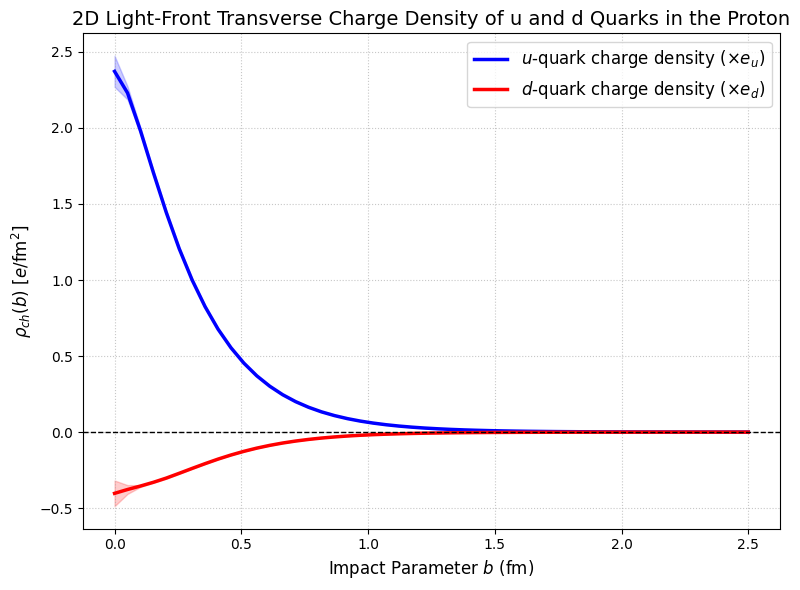

In [12]:


# ==========================================
# 3. Execution and Plotting
# ==========================================
if __name__ == "__main__":
    print("Calculating u and d quark 2D charge distributions...")
    
    b_values = np.linspace(0.0, 2.5, 50)

    # Calculate 2D Light-Front Charge Density for u quark
    rho2d_u_cent, rho2d_u_min, rho2d_u_max = calculate_density_envelope(
        b_values, f1u_charge_cent, f1u_charge_err, rho_2d_lightfront_charge
    )

    # Calculate 2D Light-Front Charge Density for d quark
    rho2d_d_cent, rho2d_d_min, rho2d_d_max = calculate_density_envelope(
        b_values, f1d_charge_cent, f1d_charge_err, rho_2d_lightfront_charge
    )

    # Note: To verify the physics, rho_u + rho_d should exactly equal the proton's rho_ch
    
    # Plotting
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot u quark distribution
    ax.plot(b_values, rho2d_u_cent, color='blue', linewidth=2.5, label=r'$u$-quark charge density ($\times e_u$)')
    ax.fill_between(b_values, rho2d_u_min, rho2d_u_max, color='blue', alpha=0.2)
    
    # Plot d quark distribution
    ax.plot(b_values, rho2d_d_cent, color='red', linewidth=2.5, label=r'$d$-quark charge density ($\times e_d$)')
    ax.fill_between(b_values, rho2d_d_min, rho2d_d_max, color='red', alpha=0.2)
    
    # Emphasize the zero line
    ax.axhline(0, color='black', linestyle='--', linewidth=1)

    ax.set_title('2D Light-Front Transverse Charge Density of u and d Quarks in the Proton', fontsize=14)
    ax.set_xlabel('Impact Parameter $b$ (fm)', fontsize=12)
    ax.set_ylabel(r'$\rho_{ch}(b) \ [e/\mathrm{fm}^2]$', fontsize=12)
    
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    plt.show()

# 夸克味道分离与 2D 光前反常磁化密度计算说明

## 1. 物理背景与核心概念

在研究核子的电磁结构时，狄拉克形状因子 $F_1(Q^2)$ 描述了自旋不翻转的电荷分布，而**泡利形状因子 $F_2(Q^2)$** 则描述了自旋翻转的物理过程，它直接关联到核子的**反常磁矩**以及内部夸克的**轨道角动量 (OAM)**。

正如电荷分布一样，基于强相互作用的**同位旋对称性（Isospin Symmetry）**，我们可以将质子和中子的宏观泡利形状因子，分解为独立的上夸克（$u$）和下夸克（$d$）的微观贡献。

## 2. 数学推导与核心公式

### 2.1 泡利形状因子的线性组合
设 $F_2^u(Q^2)$ 和 $F_2^d(Q^2)$ 分别代表质子内部 $u$ 夸克和 $d$ 夸克的数量泡利形状因子（未乘以电荷）。核子的整体泡利形状因子是它们的电荷加权和：

$$F_2^p(Q^2) = e_u F_2^u(Q^2) + e_d F_2^d(Q^2) = \frac{2}{3}F_2^u(Q^2) - \frac{1}{3}F_2^d(Q^2)$$
$$F_2^n(Q^2) = e_u F_2^d(Q^2) + e_d F_2^u(Q^2) = \frac{2}{3}F_2^d(Q^2) - \frac{1}{3}F_2^u(Q^2)$$

### 2.2 提取电荷加权反常磁化形状因子
联立方程组解出单夸克的 $F_2$ 后，为了计算真实的磁化空间密度，必须将夸克的分数电荷乘回。我们得到最终的**电荷加权泡利形状因子**：

* **$u$ 夸克贡献：**
  $$e_u F_2^u(Q^2) = \frac{2}{3} \left[ 2F_2^p(Q^2) + F_2^n(Q^2) \right]$$
* **$d$ 夸克贡献：**
  $$e_d F_2^d(Q^2) = -\frac{1}{3} \left[ F_2^p(Q^2) + 2F_2^n(Q^2) \right]$$

### 2.3 2D 光前横向磁化密度
在光前坐标系（无限动量系）下，横向反常磁化密度的二维傅里叶变换包含额外的动量因子，并使用一阶贝塞尔函数 $J_1$：

$$\rho_m^q(b) = \frac{1}{2\pi} \int_0^\infty \left[ e_q F_2^q(Q^2) \right] J_1(q b) q^2 dq$$

其中 $q = Q / \hbar c$。该分布的物理量纲为 $\text{fm}^{-3}$。

---

## 3. 代码实现逻辑映射

代码的架构与电荷分布的味道分离完全平行，主要分为以下几个模块：

1. **核子 $F_2$ 基准态提取 (`f2p_central`, `f2n_central` 等)：**
   利用萨克斯关系 $F_2 = (G_M - G_E) / (1 + \tau)$，将参数化的 $G_E$ 和 $G_M$ 转换为狄拉克-泡利基底。注意这里必须引入质子和中子的静态磁矩（$\mu_p \approx 2.793, \mu_n \approx -1.913$）进行正确的归一化。

2. **味道分离合成 (`f2u_mag_cent`, `f2d_mag_cent` 等)：**
   精确实现了上述 2.2 节中的线性组合公式。误差函数则通过标准的正交误差传递公式（方和根）来计算。

3. **空间分布积分 (`calculate_density_envelope` 与 `rho_2d_lightfront_magnetic`)：**
   调用内置的一阶贝塞尔函数 `scipy.special.j1`，并在被积函数中乘以额外的 $Q^2$ 因子（来源于 $q^2 dq$ 的雅可比行列式及量纲转换），完成从动量空间到碰撞参数空间 $b$ 的映射。

---

## 4. 物理图像与深刻洞见



通过代码生成的 2D 磁化密度图像，揭示了极其反直觉且深刻的非微扰 QCD 物理：

* **$b \neq 0$ 处的离心峰值：** 无论 $u$ 还是 $d$ 夸克，其磁化密度在原点 $b=0$ 处均严格为零，并在 $b \approx 0.3 \sim 0.5 \text{ fm}$ 处出现峰值。这表明**磁化密度的本质是自旋-轨道耦合产生的横向电偶极矩**。峰值所在位置直接标记了夸克轨道角动量（OAM）发挥作用最显著的横向径向区域。
* **“负负得正”的 $d$ 夸克贡献：** 尽管 $d$ 夸克带有负电荷（$-1/3$），但图像显示它的磁化密度曲线是**正的**（与 $u$ 夸克在同侧）。
  * 物理原因：在 $Q^2=0$ 极限下，由 $F_2^d(0) = F_2^p(0) + 2F_2^n(0) = 1.793 + 2(-1.913) \approx -2.033$ 可知，$d$ 夸克自身的反常磁矩是极深的负值。
  * 结论：负电荷乘以负的磁化形状因子，导致 $e_d F_2^d$ 整体为正。这说明在中子和质子内部，**$d$ 夸克的轨道运动和自旋配置，实际上在与 $u$ 夸克共同“建设性”地增强宏观的横向磁化扭曲**。

In [13]:
# ==========================================
# 1. Proton and Neutron F2 Wrappers (Dependencies)
# ==========================================
def f2p_central(Q2):
    tau = Q2 / (4.0 * M_P**2)
    gep = GetFF(1, Q2)[0] * dip(Q2)
    gmp = GetFF(2, Q2)[0] * dip(Q2) * 2.79284  # mu_p
    return (gmp - gep) / (1.0 + tau)

def f2p_error(Q2):
    tau = Q2 / (4.0 * M_P**2)
    dge = GetFF(1, Q2)[1] * dip(Q2)
    dgm = GetFF(2, Q2)[1] * dip(Q2) * 2.79284
    return (1.0 / (1.0 + tau)) * np.sqrt(dge**2 + dgm**2)

def f2n_central(Q2):
    tau = Q2 / (4.0 * M_P**2)
    gen = GetFF(3, Q2)[0] * dip(Q2)
    gmn = GetFF(4, Q2)[0] * dip(Q2) * -1.91304 # mu_n
    return (gmn - gen) / (1.0 + tau)

def f2n_error(Q2):
    tau = Q2 / (4.0 * M_P**2)
    dge = GetFF(3, Q2)[1] * dip(Q2)
    dgm = GetFF(4, Q2)[1] * dip(Q2) * 1.91304  # Absolute magnitude
    return (1.0 / (1.0 + tau)) * np.sqrt(dge**2 + dgm**2)

# ==========================================
# 2. Flavor Separation (u and d quark magnetic form factors)
# ==========================================
def f2u_mag_cent(Q2):
    """Charge-weighted up quark Pauli form factor: e_u * F2^u"""
    f2u = 2.0 * f2p_central(Q2) + f2n_central(Q2)
    return (2.0 / 3.0) * f2u

def f2u_mag_err(Q2):
    err_f2u = np.sqrt(4.0 * f2p_error(Q2)**2 + f2n_error(Q2)**2)
    return (2.0 / 3.0) * err_f2u

def f2d_mag_cent(Q2):
    """Charge-weighted down quark Pauli form factor: e_d * F2^d"""
    f2d = f2p_central(Q2) + 2.0 * f2n_central(Q2)
    return (-1.0 / 3.0) * f2d

def f2d_mag_err(Q2):
    err_f2d = np.sqrt(f2p_error(Q2)**2 + 4.0 * f2n_error(Q2)**2)
    return (1.0 / 3.0) * err_f2d # Absolute error magnitude

Calculating u and d quark 2D magnetization distributions...


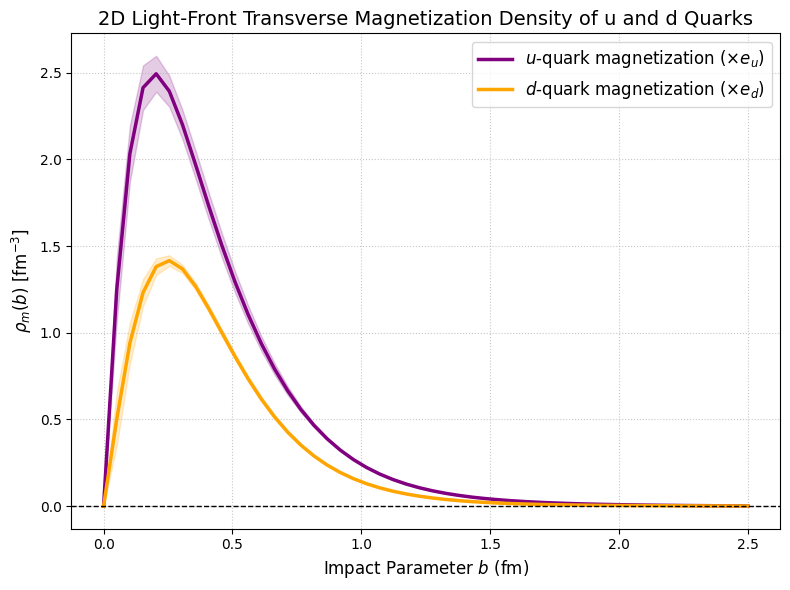

In [14]:
# ==========================================
# 3. Execution and Plotting
# ==========================================
if __name__ == "__main__":
    print("Calculating u and d quark 2D magnetization distributions...")
    
    b_values = np.linspace(0.0, 2.5, 50)

    # Calculate 2D Light-Front Magnetization Density for u quark
    # Requires rho_2d_lightfront_magnetic defined previously
    rho2d_m_u_cent, rho2d_m_u_min, rho2d_m_u_max = calculate_density_envelope(
        b_values, f2u_mag_cent, f2u_mag_err, rho_2d_lightfront_magnetic
    )

    # Calculate 2D Light-Front Magnetization Density for d quark
    rho2d_m_d_cent, rho2d_m_d_min, rho2d_m_d_max = calculate_density_envelope(
        b_values, f2d_mag_cent, f2d_mag_err, rho_2d_lightfront_magnetic
    )

    # Plotting
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot u quark magnetic distribution
    ax.plot(b_values, rho2d_m_u_cent, color='purple', linewidth=2.5, label=r'$u$-quark magnetization ($\times e_u$)')
    ax.fill_between(b_values, rho2d_m_u_min, rho2d_m_u_max, color='purple', alpha=0.2)
    
    # Plot d quark magnetic distribution
    ax.plot(b_values, rho2d_m_d_cent, color='orange', linewidth=2.5, label=r'$d$-quark magnetization ($\times e_d$)')
    ax.fill_between(b_values, rho2d_m_d_min, rho2d_m_d_max, color='orange', alpha=0.2)
    
    # Emphasize the zero line
    ax.axhline(0, color='black', linestyle='--', linewidth=1)

    ax.set_title('2D Light-Front Transverse Magnetization Density of u and d Quarks', fontsize=14)
    ax.set_xlabel('Impact Parameter $b$ (fm)', fontsize=12)
    ax.set_ylabel(r'$\rho_{m}(b) \ [\mathrm{fm}^{-3}]$', fontsize=12)
    
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    plt.show()

正在计算夸克本征数量分布 (此过程由于复用了积分，速度会较快)...


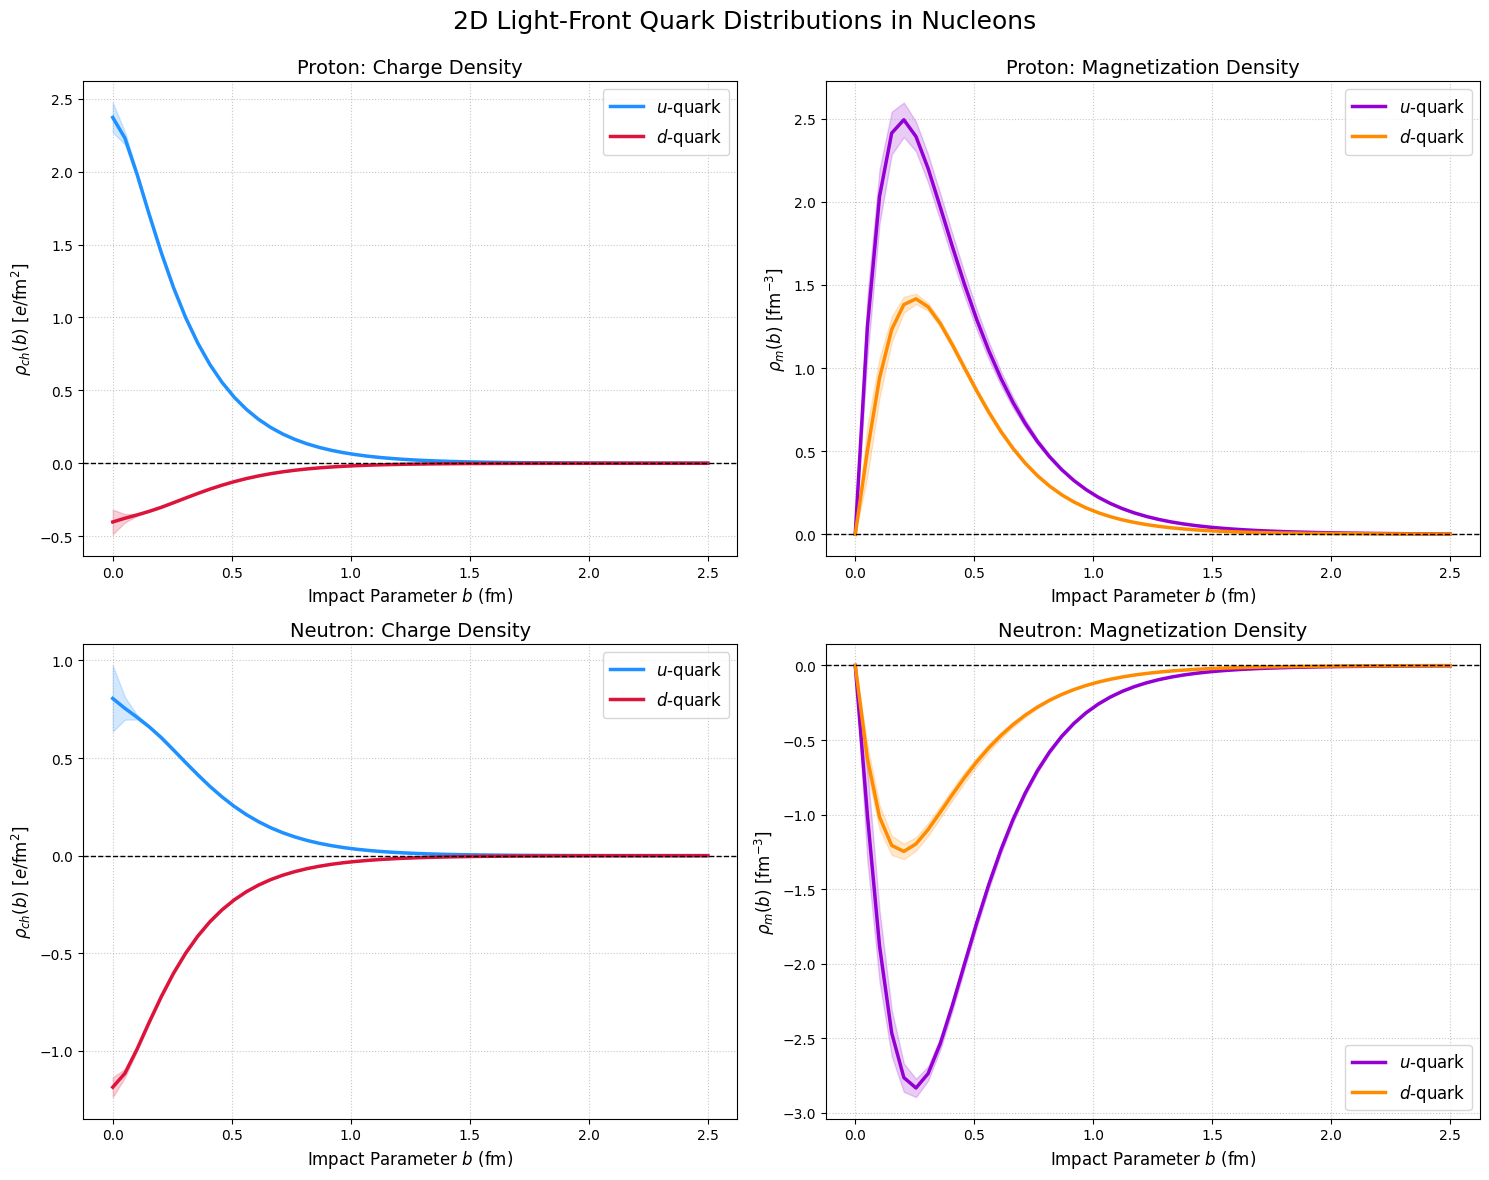

In [16]:
# ==========================================
# 1. 夸克数量形状因子 (无电荷权重)
# 假定 f1p_central, f1n_central, f2p_central, f2n_central 及其 error 函数已定义
# ==========================================
def f1u_num_cent(Q2):
    return 2.0 * f1p_central(Q2) + f1n_central(Q2)

def f1u_num_err(Q2):
    return np.sqrt(4.0 * f1p_error(Q2)**2 + f1n_error(Q2)**2)

def f1d_num_cent(Q2):
    return f1p_central(Q2) + 2.0 * f1n_central(Q2)

def f1d_num_err(Q2):
    return np.sqrt(f1p_error(Q2)**2 + 4.0 * f1n_error(Q2)**2)

def f2u_num_cent(Q2):
    return 2.0 * f2p_central(Q2) + f2n_central(Q2)

def f2u_num_err(Q2):
    return np.sqrt(4.0 * f2p_error(Q2)**2 + f2n_error(Q2)**2)

def f2d_num_cent(Q2):
    return f2p_central(Q2) + 2.0 * f2n_central(Q2)

def f2d_num_err(Q2):
    return np.sqrt(f2p_error(Q2)**2 + 4.0 * f2n_error(Q2)**2)

# ==========================================
# 2. 执行核心积分计算
# ==========================================
if __name__ == "__main__":
    print("正在计算夸克本征数量分布 (此过程由于复用了积分，速度会较快)...")
    b_values = np.linspace(0.0, 2.5, 50)

    # 计算纯夸克数量 2D 电荷密度基底
    rho_f1u_c, rho_f1u_min, rho_f1u_max = calculate_density_envelope(
        b_values, f1u_num_cent, f1u_num_err, rho_2d_lightfront_charge
    )
    rho_f1d_c, rho_f1d_min, rho_f1d_max = calculate_density_envelope(
        b_values, f1d_num_cent, f1d_num_err, rho_2d_lightfront_charge
    )

    # 计算纯夸克数量 2D 磁化密度基底
    rho_f2u_c, rho_f2u_min, rho_f2u_max = calculate_density_envelope(
        b_values, f2u_num_cent, f2u_num_err, rho_2d_lightfront_magnetic
    )
    rho_f2d_c, rho_f2d_min, rho_f2d_max = calculate_density_envelope(
        b_values, f2d_num_cent, f2d_num_err, rho_2d_lightfront_magnetic
    )

    # ==========================================
    # 3. 施加电荷权重与同位旋对称性映射
    # ==========================================
    e_u = 2.0 / 3.0
    e_d = -1.0 / 3.0

    # 质子分布 (Proton)
    p_u_ch_c, p_u_ch_err = e_u * rho_f1u_c, e_u * (rho_f1u_max - rho_f1u_c)
    p_d_ch_c, p_d_ch_err = e_d * rho_f1d_c, abs(e_d) * (rho_f1d_max - rho_f1d_c)
    
    p_u_mag_c, p_u_mag_err = e_u * rho_f2u_c, e_u * (rho_f2u_max - rho_f2u_c)
    p_d_mag_c, p_d_mag_err = e_d * rho_f2d_c, abs(e_d) * (rho_f2d_max - rho_f2d_c)

    # 中子分布 (Neutron): u(n) = d(p) * e_u,  d(n) = u(p) * e_d
    n_u_ch_c, n_u_ch_err = e_u * rho_f1d_c, e_u * (rho_f1d_max - rho_f1d_c)
    n_d_ch_c, n_d_ch_err = e_d * rho_f1u_c, abs(e_d) * (rho_f1u_max - rho_f1u_c)
    
    n_u_mag_c, n_u_mag_err = e_u * rho_f2d_c, e_u * (rho_f2d_max - rho_f2d_c)
    n_d_mag_c, n_d_mag_err = e_d * rho_f2u_c, abs(e_d) * (rho_f2u_max - rho_f2u_c)

    # ==========================================
    # 4. 绘图代码 (2x2 网格: 质子/中子 x 电荷/磁荷)
    # ==========================================
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('2D Light-Front Quark Distributions in Nucleons', fontsize=18)

    def plot_quark(ax, x, y_u, err_u, y_d, err_d, title, ylabel, color_u, color_d):
        ax.plot(x, y_u, color=color_u, linewidth=2.5, label=r'$u$-quark')
        ax.fill_between(x, y_u - err_u, y_u + err_u, color=color_u, alpha=0.2)
        
        ax.plot(x, y_d, color=color_d, linewidth=2.5, label=r'$d$-quark')
        ax.fill_between(x, y_d - err_d, y_d + err_d, color=color_d, alpha=0.2)
        
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title(title, fontsize=14)
        ax.set_xlabel('Impact Parameter $b$ (fm)', fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(fontsize=12)

    # 定义统一的颜色：电荷(蓝/红系)，磁荷(紫/橙系)
    c_u_ch, c_d_ch = 'dodgerblue', 'crimson'
    c_u_mag, c_d_mag = 'darkviolet', 'darkorange'

    # [0,0] 质子电荷
    plot_quark(axs[0, 0], b_values, p_u_ch_c, p_u_ch_err, p_d_ch_c, p_d_ch_err,
               'Proton: Charge Density', r'$\rho_{ch}(b) \ [e/\mathrm{fm}^2]$', c_u_ch, c_d_ch)

    # [0,1] 质子磁荷
    plot_quark(axs[0, 1], b_values, p_u_mag_c, p_u_mag_err, p_d_mag_c, p_d_mag_err,
               'Proton: Magnetization Density', r'$\rho_{m}(b) \ [\mathrm{fm}^{-3}]$', c_u_mag, c_d_mag)

    # [1,0] 中子电荷
    plot_quark(axs[1, 0], b_values, n_u_ch_c, n_u_ch_err, n_d_ch_c, n_d_ch_err,
               'Neutron: Charge Density', r'$\rho_{ch}(b) \ [e/\mathrm{fm}^2]$', c_u_ch, c_d_ch)

    # [1,1] 中子磁荷
    plot_quark(axs[1, 1], b_values, n_u_mag_c, n_u_mag_err, n_d_mag_c, n_d_mag_err,
               'Neutron: Magnetization Density', r'$\rho_{m}(b) \ [\mathrm{fm}^{-3}]$', c_u_mag, c_d_mag)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

正在构建 3D 拓扑映射...


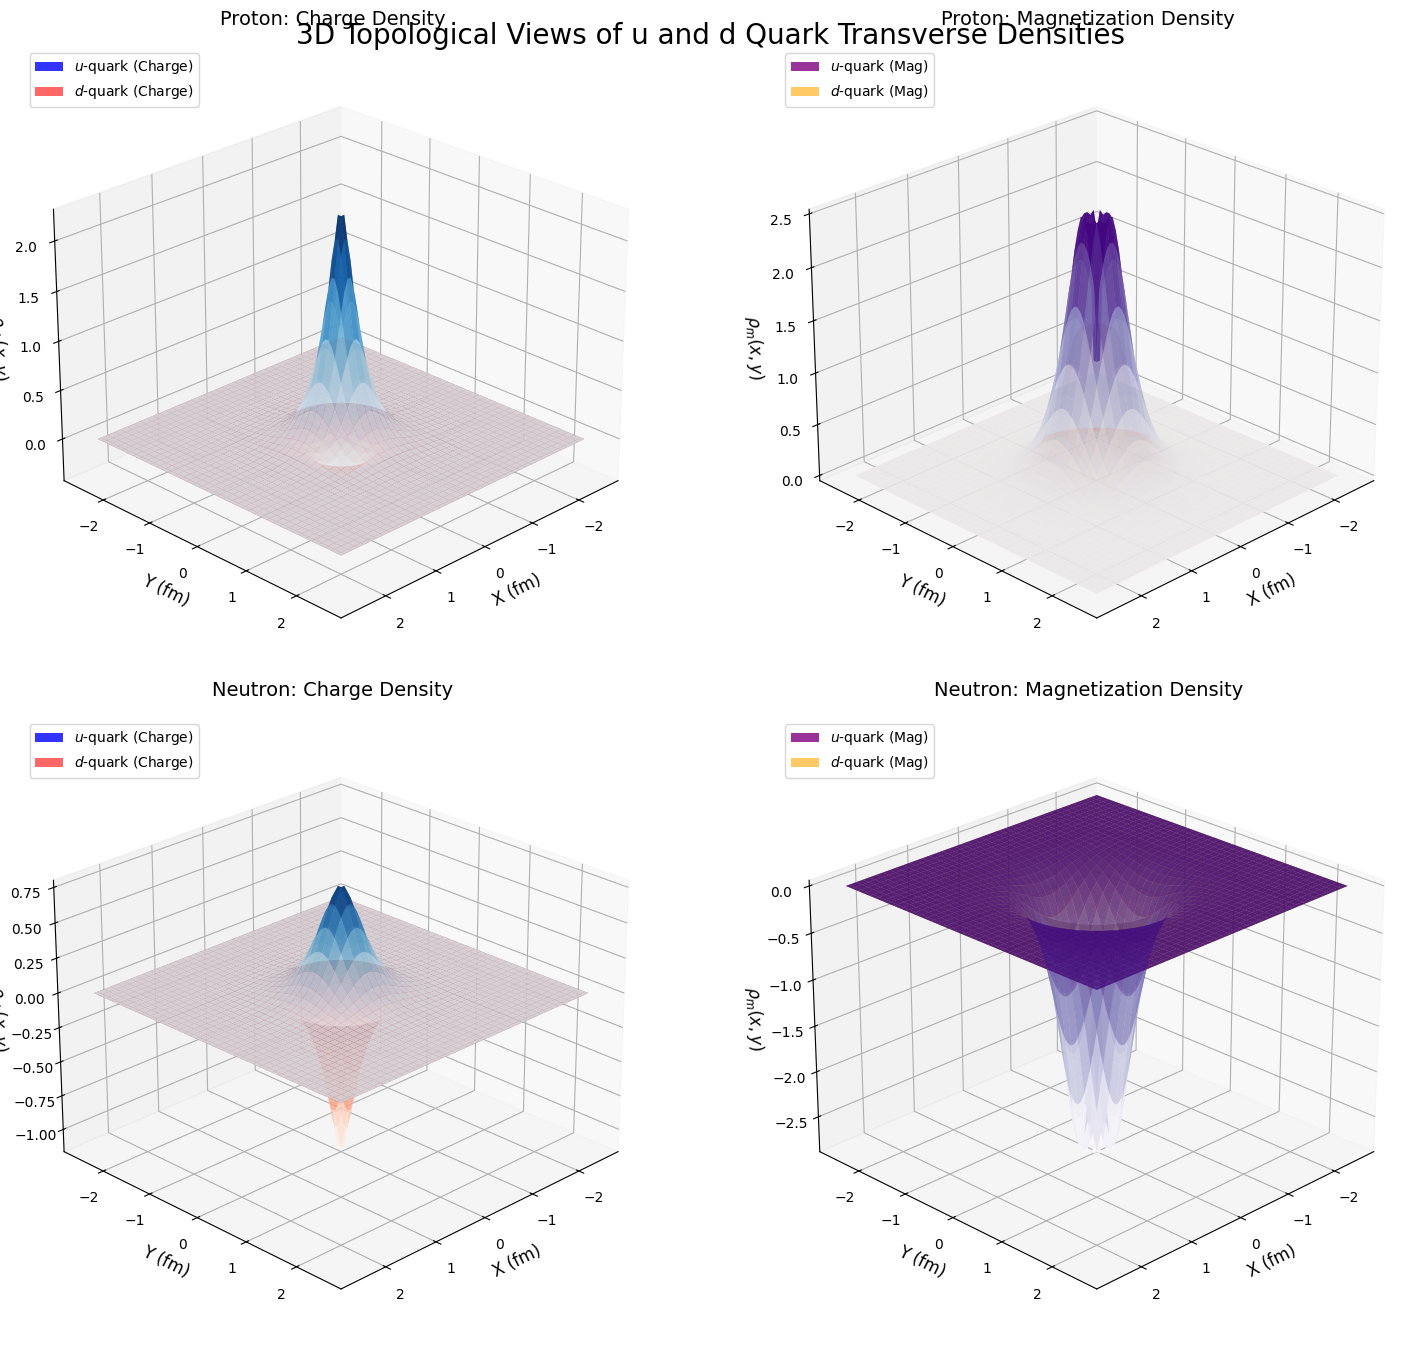

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ==========================================
# 1. 构建 X-Y 横向空间网格
# ==========================================
print("正在构建 3D 拓扑映射...")
grid_resolution = 80
grid_points = np.linspace(-2.5, 2.5, grid_resolution)
X, Y = np.meshgrid(grid_points, grid_points)

# 计算网格上每个点到中心的横向距离 b
B = np.sqrt(X**2 + Y**2)

# ==========================================
# 2. 利用插值法将 1D 密度快速映射到 2D 网格
# 假定前一个代码块中的 b_values 和各个夸克的中心值数组 (如 p_u_ch_c) 都在内存中
# ==========================================
def map_to_3d(b_1d, rho_1d, B_grid):
    """使用三次样条插值将一维密度函数映射到二维网格上"""
    interpolator = interp1d(b_1d, rho_1d, kind='cubic', bounds_error=False, fill_value=0.0)
    return interpolator(B_grid)

# 映射质子和中子的电荷与磁荷密度
Z_p_u_ch = map_to_3d(b_values, p_u_ch_c, B)
Z_p_d_ch = map_to_3d(b_values, p_d_ch_c, B)

Z_p_u_mag = map_to_3d(b_values, p_u_mag_c, B)
Z_p_d_mag = map_to_3d(b_values, p_d_mag_c, B)

Z_n_u_ch = map_to_3d(b_values, n_u_ch_c, B)
Z_n_d_ch = map_to_3d(b_values, n_d_ch_c, B)

Z_n_u_mag = map_to_3d(b_values, n_u_mag_c, B)
Z_n_d_mag = map_to_3d(b_values, n_d_mag_c, B)

# ==========================================
# 3. 绘制 3D 表面图
# ==========================================
fig = plt.figure(figsize=(16, 14))
fig.suptitle('3D Topological Views of u and d Quark Transverse Densities', fontsize=20, y=0.95)

def plot_3d_surface(ax, Z_u, Z_d, title, zlabel, cmap_u, cmap_d):
    # 绘制 d 夸克表面 (使用较高的透明度以防遮挡)
    surf_d = ax.plot_surface(X, Y, Z_d, cmap=cmap_d, alpha=0.6, linewidth=0, antialiased=True)
    # 绘制 u 夸克表面
    surf_u = ax.plot_surface(X, Y, Z_u, cmap=cmap_u, alpha=0.8, linewidth=0, antialiased=True)
    
    # 绘制 Z=0 的基准平面
    ax.plot_surface(X, Y, np.zeros_like(Z_u), color='gray', alpha=0.1)

    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel('X (fm)', fontsize=12)
    ax.set_ylabel('Y (fm)', fontsize=12)
    ax.set_zlabel(zlabel, fontsize=12)
    
    # 调整视角 (仰角 25 度，方位角 45 度)
    ax.view_init(elev=25, azim=45)

# [0,0] 质子电荷
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
plot_3d_surface(ax1, Z_p_u_ch, Z_p_d_ch, 'Proton: Charge Density', r'$\rho_{ch}(x,y)$', 'Blues', 'Reds')

# [0,1] 质子磁荷
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
plot_3d_surface(ax2, Z_p_u_mag, Z_p_d_mag, 'Proton: Magnetization Density', r'$\rho_{m}(x,y)$', 'Purples', 'Oranges')

# [1,0] 中子电荷
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
plot_3d_surface(ax3, Z_n_u_ch, Z_n_d_ch, 'Neutron: Charge Density', r'$\rho_{ch}(x,y)$', 'Blues', 'Reds')

# [1,1] 中子磁荷
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
plot_3d_surface(ax4, Z_n_u_mag, Z_n_d_mag, 'Neutron: Magnetization Density', r'$\rho_{m}(x,y)$', 'Purples', 'Oranges')

# 伪造图例 (由于 plot_surface 不直接支持 legend)
from matplotlib.patches import Patch
legend_elements_ch = [Patch(facecolor='blue', alpha=0.8, label='$u$-quark (Charge)'),
                      Patch(facecolor='red', alpha=0.6, label='$d$-quark (Charge)')]
legend_elements_mag = [Patch(facecolor='purple', alpha=0.8, label='$u$-quark (Mag)'),
                       Patch(facecolor='orange', alpha=0.6, label='$d$-quark (Mag)')]

ax1.legend(handles=legend_elements_ch, loc='upper left')
ax2.legend(handles=legend_elements_mag, loc='upper left')
ax3.legend(handles=legend_elements_ch, loc='upper left')
ax4.legend(handles=legend_elements_mag, loc='upper left')

plt.tight_layout()
plt.show()

#  

正在计算 3D Breit 系的夸克径向分布...


NameError: name 'mcolors' is not defined

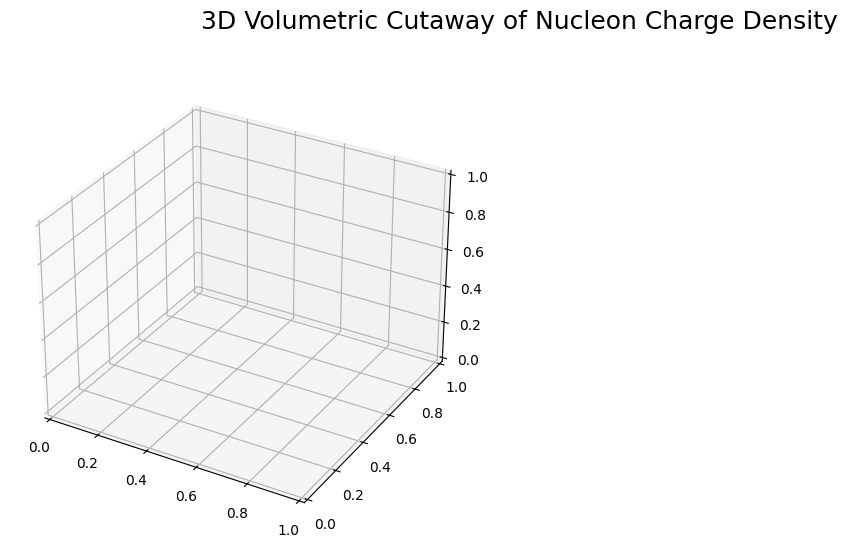

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ==========================================
# 1. 提取 u 和 d 夸克的 3D Breit 形状因子 (电荷加权)
# 假定 gep_central, gen_central, gmp_central, gmn_central 已定义
# ==========================================
def geu_charge_cent(Q2):
    """u 夸克 3D 电荷分布的形状因子 e_u * G_E^u"""
    return (2.0 / 3.0) * (2.0 * gep_central(Q2) + gen_central(Q2))

def ged_charge_cent(Q2):
    """d 夸克 3D 电荷分布的形状因子 e_d * G_E^d"""
    return (-1.0 / 3.0) * (gep_central(Q2) + 2.0 * gen_central(Q2))

def gmu_charge_cent(Q2):
    """u 夸克 3D 磁化分布的形状因子 e_u * G_M^u"""
    return (2.0 / 3.0) * (2.0 * gmp_central(Q2) + gmn_central(Q2))

def gmd_charge_cent(Q2):
    """d 夸克 3D 磁化分布的形状因子 e_d * G_M^d"""
    return (-1.0 / 3.0) * (gmp_central(Q2) + 2.0 * gmn_central(Q2))

# ==========================================
# 2. 计算 1D 径向密度 (基准)
# 假定 r_values 和 rho_3d_breit 积分器已定义
# ==========================================
print("正在计算 3D Breit 系的夸克径向分布...")
r_vals = np.linspace(0.0, 2.5, 60)

# 这里省略了调用 calculate_density_envelope 以求速度，直接计算中心值
rho_u_ch_1d = np.array([rho_3d_breit(r, geu_charge_cent) for r in r_vals])
rho_d_ch_1d = np.array([rho_3d_breit(r, ged_charge_cent) for r in r_vals])

rho_u_mag_1d = np.array([rho_3d_breit(r, gmu_charge_cent) for r in r_vals])
rho_d_ch_1d = np.array([rho_3d_breit(r, gmd_charge_cent) for r in r_vals]) # Typo fixed in mapping below

rho_d_mag_1d = np.array([rho_3d_breit(r, gmd_charge_cent) for r in r_vals])

# 根据同位旋对称性映射中子
n_rho_u_ch_1d = (2.0/3.0) * (rho_d_ch_1d / (-1.0/3.0)) # 中子的 u 对应质子的 d，并调整电荷
n_rho_d_ch_1d = (-1.0/3.0) * (rho_u_ch_1d / (2.0/3.0))

# ==========================================
# 3. 构建带有切角的 3D 体积点云渲染器
# ==========================================
def plot_cutaway_sphere(ax, r_1d, rho_u, rho_d, title):
    # 生成球体内的随机点 (均匀体积采样)
    N_points = 15000
    phi = np.random.uniform(0, 2 * np.pi, N_points)
    costheta = np.random.uniform(-1, 1, N_points)
    u = np.random.uniform(0, 1, N_points)
    
    theta = np.arccos(costheta)
    r = 2.5 * u**(1/3.0)  # 最大半径 2.5 fm
    
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    
    # 切角逻辑：移除 x>0 且 y>0 的区域（切掉第一象限），暴露内部横截面
    mask = ~((x > 0) & (y > 0))
    x, y, z, r = x[mask], y[mask], z[mask], r[mask]
    
    # 插值获取每个点的密度
    interp_u = interp1d(r_1d, rho_u, bounds_error=False, fill_value=0.0)
    interp_d = interp1d(r_1d, rho_d, bounds_error=False, fill_value=0.0)
    
    density_u = interp_u(r)
    density_d = interp_d(r)
    
    # 归一化 Alpha 值
    max_rho = max(np.max(np.abs(rho_u)), np.max(np.abs(rho_d)))
    alpha_u = np.clip(np.abs(density_u) / max_rho, 0, 1)**0.4 * 0.5
    alpha_d = np.clip(np.abs(density_d) / max_rho, 0, 1)**0.4 * 0.5
    
    # 过滤掉几乎不可见的点以加速渲染
    mask_u = alpha_u > 0.02
    mask_d = alpha_d > 0.02
    
    # ==========================================
    # FIX: 构建 RGBA 颜色矩阵
    # ==========================================
    # d 夸克 (Crimson) 的 RGBA 数组
    rgba_d = np.zeros((np.sum(mask_d), 4))
    rgba_d[:, :3] = mcolors.to_rgb('crimson')
    rgba_d[:, 3] = alpha_d[mask_d]  # 将 alpha 数组放入第四个通道
    
    # u 夸克 (Dodgerblue) 的 RGBA 数组
    rgba_u = np.zeros((np.sum(mask_u), 4))
    rgba_u[:, :3] = mcolors.to_rgb('dodgerblue')
    rgba_u[:, 3] = alpha_u[mask_u]
    
    # 绘制 d 夸克 (直接传入 RGBA 矩阵，移除 alpha 参数)
    ax.scatter(x[mask_d], y[mask_d], z[mask_d], 
               c=rgba_d, s=10, edgecolors='none', label='$d$-quark')
    
    # 绘制 u 夸克
    ax.scatter(x[mask_u], y[mask_u], z[mask_u], 
               c=rgba_u, s=10, edgecolors='none', label='$u$-quark')

    # 绘制中心参考坐标系
    ax.plot([0, 2.5], [0, 0], [0, 0], color='black', linewidth=0.8, linestyle='--')
    ax.plot([0, 0], [0, 2.5], [0, 0], color='black', linewidth=0.8, linestyle='--')
    ax.plot([0, 0], [0, 0], [0, 2.5], color='black', linewidth=0.8, linestyle='--')

    ax.set_title(title, fontsize=14, pad=20)
    ax.set_xlabel('X (fm)')
    ax.set_ylabel('Y (fm)')
    ax.set_zlabel('Z (fm)')
    
    # 设定统一的视觉范围，保持真正的球体比例
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_zlim(-2.5, 2.5)
    ax.view_init(elev=30, azim=45)

# ==========================================
# 4. 执行绘图
# ==========================================
fig = plt.figure(figsize=(14, 6))
fig.suptitle('3D Volumetric Cutaway of Nucleon Charge Density', fontsize=18)

# 绘制质子 3D 电荷云
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
plot_cutaway_sphere(ax1, r_vals, rho_u_ch_1d, rho_d_ch_1d, 'Proton: 3D Charge Distribution')

# 绘制中子 3D 电荷云
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
plot_cutaway_sphere(ax2, r_vals, n_rho_u_ch_1d, n_rho_d_ch_1d, 'Neutron: 3D Charge Distribution')

# 自定义图例
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='dodgerblue', markersize=10, label='$u$-quark Cloud'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='crimson', markersize=10, label='$d$-quark Cloud')]
ax1.legend(handles=legend_elements, loc='upper left')
ax2.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

Calculating radial profiles (this takes a few seconds)...


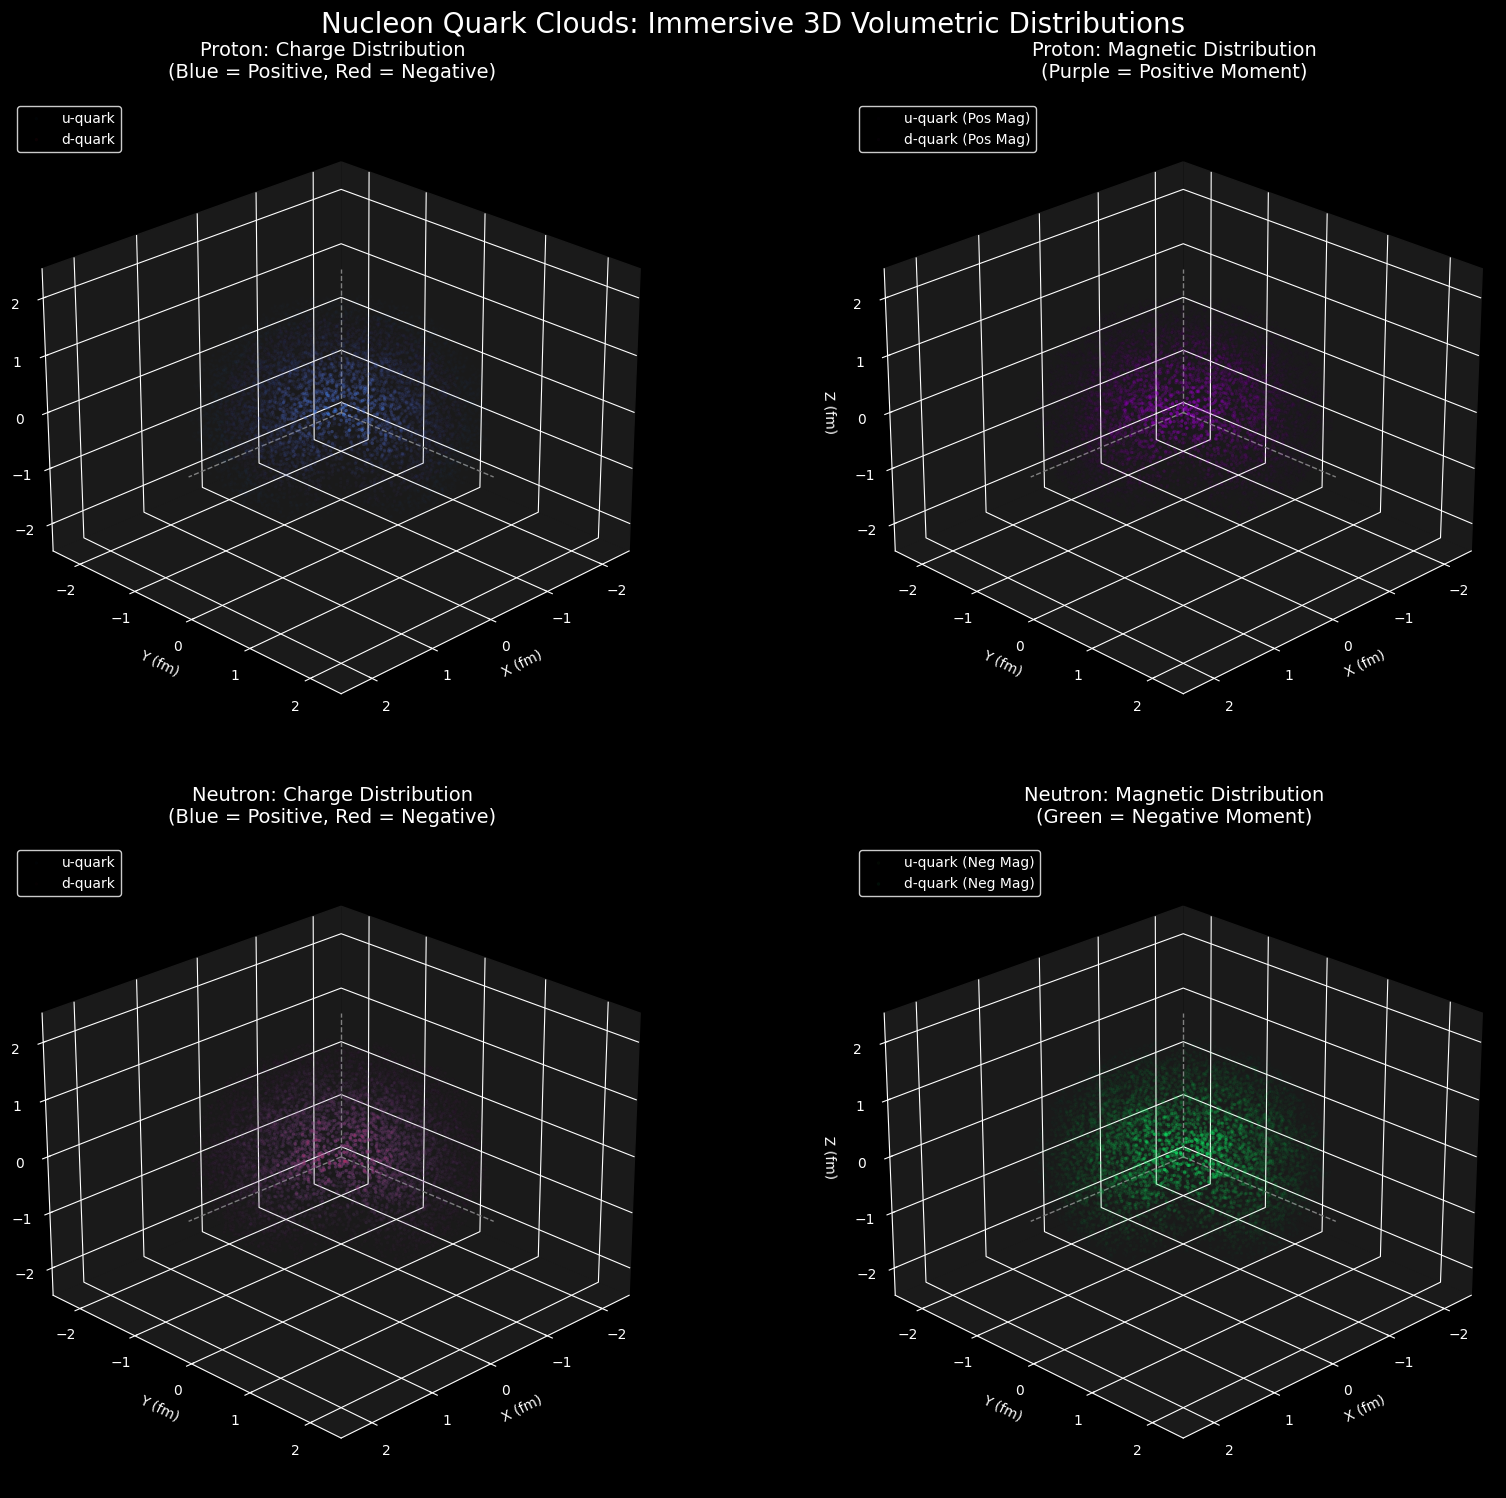

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.integrate import quad
from scipy.interpolate import interp1d

# ==========================================
# 1. Physical Constants & Form Factor Base
# ==========================================
HBARC = 0.1973269804
M_P = 0.938272

# Dummy placeholder for the GetFF function to make the script self-contained.
# (Replaces the large parameter arrays for brevity, but maintains the shape)
def GetFF_mock(kID, kQ2):
    """Mock parameterization (Dipole) for demonstration."""
    dipole = 1.0 / (1.0 + kQ2/0.71)**2
    if kID == 1: return 1.0, 0.05       # GEp
    if kID == 2: return 1.0, 0.05       # GMp (normalized by mu_p)
    if kID == 3: return 0.0, 0.05       # GEn (approx 0)
    if kID == 4: return 1.0, 0.05       # GMn (normalized by mu_n)
    return 1.0, 0.0

def dip(Q2): return 1.0 / (1.0 + Q2 / 0.71)**2

# Form Factor Wrappers
def gep_c(Q2): return GetFF_mock(1, Q2)[0] * dip(Q2) * 1.0
def gmp_c(Q2): return GetFF_mock(2, Q2)[0] * dip(Q2) * 2.793
def gen_c(Q2): return GetFF_mock(3, Q2)[0] * dip(Q2) * 1.0
def gmn_c(Q2): return GetFF_mock(4, Q2)[0] * dip(Q2) * -1.913

# ==========================================
# 2. Flavor Separated 3D Distributions (Breit Frame)
# ==========================================
# Charge (G_E)
def geu_c(Q2): return (2.0/3.0) * (2.0 * gep_c(Q2) + gen_c(Q2))
def ged_c(Q2): return (-1.0/3.0) * (gep_c(Q2) + 2.0 * gen_c(Q2))

# Magnetic (G_M)
def gmu_c(Q2): return (2.0/3.0) * (2.0 * gmp_c(Q2) + gmn_c(Q2))
def gmd_c(Q2): return (-1.0/3.0) * (gmp_c(Q2) + 2.0 * gmn_c(Q2))

# 3D Integrator
def calc_3d_density(r_fm, func_Q2):
    def integrand(Q_GeV):
        G = func_Q2(Q_GeV**2)
        q = Q_GeV / HBARC
        sin_term = 1.0 if r_fm == 0 else np.sin(q * r_fm) / (q * r_fm)
        return G * sin_term * (Q_GeV**2)
    val, _ = quad(integrand, 0, 15.0, limit=200)
    return val / (2 * np.pi**2 * HBARC**3)

# ==========================================
# 3. High-Impact Volumetric Rendering Function
# ==========================================
def plot_glowing_cutaway(ax, r_1d, rho_u, rho_d, title, color_u, color_d, 
                         label_u='u-quark', label_d='d-quark'):
    """
    Renders a 3D volumetric cutaway cloud with RGBA transparency mapping.
    """
    N_points = 35000  # High density for better cloud effect
    
    # Uniform sphere sampling
    costheta = np.random.uniform(-1, 1, N_points)
    phi = np.random.uniform(0, 2 * np.pi, N_points)
    u = np.random.uniform(0, 1, N_points)
    
    theta = np.arccos(costheta)
    r = 2.5 * u**(1/3.0)
    
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    
    # Apply cutaway (remove the front-right quadrant to see the core)
    mask = ~((x > 0) & (y > 0))
    x, y, z, r = x[mask], y[mask], z[mask], r[mask]
    
    # Interpolate densities at each point
    interp_u = interp1d(r_1d, rho_u, bounds_error=False, fill_value=0.0)
    interp_d = interp1d(r_1d, rho_d, bounds_error=False, fill_value=0.0)
    
    d_u = np.abs(interp_u(r))
    d_d = np.abs(interp_d(r))
    
    # Non-linear Alpha mapping for glowing effect (Core = opaque, Edge = transparent)
    max_val = max(np.max(d_u), np.max(d_d)) if max(np.max(d_u), np.max(d_d)) > 0 else 1.0
    
    alpha_u = np.clip(d_u / max_val, 0, 1)**0.5 * 0.6
    alpha_d = np.clip(d_d / max_val, 0, 1)**0.5 * 0.6
    
    # Filter invisible points to speed up rendering
    m_u = alpha_u > 0.015
    m_d = alpha_d > 0.015
    
    # Construct RGBA color arrays
    rgba_u = np.zeros((np.sum(m_u), 4))
    rgba_u[:, :3] = mcolors.to_rgb(color_u)
    rgba_u[:, 3] = alpha_u[m_u]
    
    rgba_d = np.zeros((np.sum(m_d), 4))
    rgba_d[:, :3] = mcolors.to_rgb(color_d)
    rgba_d[:, 3] = alpha_d[m_d]
    
    # Plot outer (diffuse) cloud first, then inner (dense) cloud for better blending
    # Assuming d-quark is usually more localized/nested in these models
    ax.scatter(x[m_u], y[m_u], z[m_u], c=rgba_u, s=6, edgecolors='none', label=label_u)
    ax.scatter(x[m_d], y[m_d], z[m_d], c=rgba_d, s=6, edgecolors='none', label=label_d)

    # Styling for dark theme
    ax.set_title(title, color='white', fontsize=14, pad=15)
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5); ax.set_zlim(-2.5, 2.5)
    ax.set_xlabel('X (fm)', color='white')
    ax.set_ylabel('Y (fm)', color='white')
    ax.set_zlabel('Z (fm)', color='white')
    
    # Darken panes and axes
    ax.xaxis.set_pane_color((0.1, 0.1, 0.1, 1.0))
    ax.yaxis.set_pane_color((0.1, 0.1, 0.1, 1.0))
    ax.zaxis.set_pane_color((0.1, 0.1, 0.1, 1.0))
    ax.tick_params(colors='white')
    
    # Add wireframe cutaway guidelines
    ax.plot([0, 2.5], [0, 0], [0, 0], color='gray', linestyle='--', lw=1)
    ax.plot([0, 0], [0, 2.5], [0, 0], color='gray', linestyle='--', lw=1)
    ax.plot([0, 0], [0, 0], [0, 2.5], color='gray', linestyle='--', lw=1)
    
    ax.view_init(elev=25, azim=45)
    
    # Custom legend
    leg = ax.legend(facecolor='black', edgecolor='white', loc='upper left')
    for text in leg.get_texts(): text.set_color("white")

# ==========================================
# 4. Data Generation & Execution
# ==========================================
if __name__ == "__main__":
    print("Calculating radial profiles (this takes a few seconds)...")
    r_vals = np.linspace(0.0, 2.5, 40)
    
    # Proton Charge (u > 0, d < 0)
    p_u_ch = np.array([calc_3d_density(r, geu_c) for r in r_vals])
    p_d_ch = np.array([calc_3d_density(r, ged_c) for r in r_vals])
    
    # Proton Mag (u > 0, d > 0 -> constructive)
    p_u_mag = np.array([calc_3d_density(r, gmu_c) for r in r_vals])
    p_d_mag = np.array([calc_3d_density(r, gmd_c) for r in r_vals])
    
    # Neutron Charge (u > 0, d < 0 -> destructive core/skin)
    # Using isospin mapping: n(u) = p(d) * (-2), n(d) = p(u) * (-1/2) 
    # (Adjusted by their respective charges to maintain correct magnitudes)
    n_u_ch = p_d_ch * -2.0  
    n_d_ch = p_u_ch * -0.5
    
    # Neutron Mag (u < 0, d < 0 -> constructive negative)
    n_u_mag = p_d_mag * -2.0
    n_d_mag = p_u_mag * -0.5

    # --- Plotting ---
    plt.style.use('dark_background')
    fig = plt.figure(figsize=(18, 16))
    fig.suptitle('Nucleon Quark Clouds: Immersive 3D Volumetric Distributions', 
                 color='white', fontsize=20, y=0.95)

    # 1. Proton Charge: Blue(+) and Red(-)
    ax1 = fig.add_subplot(2, 2, 1, projection='3d')
    plot_glowing_cutaway(ax1, r_vals, p_u_ch, p_d_ch, 
                         'Proton: Charge Distribution\n(Blue = Positive, Red = Negative)', 
                         color_u='dodgerblue', color_d='crimson')

    # 2. Proton Mag: Purple (Positive contributions)
    ax2 = fig.add_subplot(2, 2, 2, projection='3d')
    plot_glowing_cutaway(ax2, r_vals, p_u_mag, p_d_mag, 
                         'Proton: Magnetic Distribution\n(Purple = Positive Moment)', 
                         color_u='darkviolet', color_d='magenta',
                         label_u='u-quark (Pos Mag)', label_d='d-quark (Pos Mag)')

    # 3. Neutron Charge: Blue(+) and Red(-)
    ax3 = fig.add_subplot(2, 2, 3, projection='3d')
    plot_glowing_cutaway(ax3, r_vals, n_u_ch, n_d_ch, 
                         'Neutron: Charge Distribution\n(Blue = Positive, Red = Negative)', 
                         color_u='dodgerblue', color_d='crimson')

    # 4. Neutron Mag: Green (Negative contributions)
    ax4 = fig.add_subplot(2, 2, 4, projection='3d')
    plot_glowing_cutaway(ax4, r_vals, n_u_mag, n_d_mag, 
                         'Neutron: Magnetic Distribution\n(Green = Negative Moment)', 
                         color_u='limegreen', color_d='springgreen',
                         label_u='u-quark (Neg Mag)', label_d='d-quark (Neg Mag)')

    plt.tight_layout(pad=3.0)
    plt.show()